In [1]:
# Imports done at the beginning of the Python notebook.

# Just for clearing the outputs, removing Python warnings.
import warnings

import matplotlib.pyplot as plt
import pandas
import seaborn

warnings.filterwarnings("ignore")

In [2]:
def diagnostic_plots(df, variable, target, save):
    """Render a 4-panel diagnostic view (histogram, scatter vs target,
    boxplot, barplot vs target) for one feature -- used to eyeball a
    continuous feature's distribution and its relationship with the PE
    label before deciding whether/how to use it."""
    plt.figure(figsize=(20, 7))

    # histogram
    plt.subplot(1, 4, 1)
    seaborn.histplot(df[variable], kde=True, color='r')
    plt.title('Histogram')

    # scatterplot
    plt.subplot(1, 4, 2)
    plt.scatter(df[variable], df[target], color='g')
    plt.title('Scatterplot')

    # boxplot
    plt.subplot(1, 4, 3)
    seaborn.boxplot(y=df[variable], color='b')
    plt.title('Boxplot')

    # barplot
    plt.subplot(1, 4, 4)
    seaborn.barplot(x=target, y=variable, data=df)
    plt.title('Barplot')

    if save:
        plt.savefig(variable + ".pdf")
    plt.show()

## **DATASET-LABELS**

The ground-truth table: one row per patient (`idx`), the binary PE `label`
(1 = pulmonary embolism confirmed on CT), the `pe_type` sub-classification
(only populated for PE-positive patients), and the official RadFusion
`split` (train/val/test) assignment. Every other table is inspected for
uniqueness/completeness against **this** table's `idx` set, since it defines
which 1837 patients the final dataset must contain.

Every table in this notebook gets the same basic due-diligence pass before
use: null-value counts, a duplicate-row check, and (where the raw file has
more rows than patients) a duplicate-`idx` check -- this is what the
repeated "Null values count" / "Is there any duplications" cells below and
in later sections are for.

In [3]:
original_data_labels = pandas.read_csv("Labels.csv")

In [4]:
original_data_labels.head()

,Unnamed: 0,idx,label,pe_type,split
0,0,1436,0,NaN,train
1,1,1880,1,segmental,train
2,2,2738,0,NaN,val
3,3,2883,0,NaN,train
4,4,2302,1,segmental,train


In [5]:
original_data_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  1837 non-null   int64
 1   idx         1837 non-null   int64
 2   label       1837 non-null   int64
 3   pe_type     726 non-null    str  
 4   split       1837 non-null   str  
dtypes: int64(3), str(2)
memory usage: 71.9 KB


In [6]:
print("Null values count:")
print(original_data_labels.isnull().sum())

Null values count:
Unnamed: 0       0
idx              0
label            0
pe_type       1111
split            0
dtype: int64


In [7]:
print("Is there any duplications:")
print(original_data_labels.duplicated().any())

Is there any duplications:
False


In [8]:
print(f"Patient count: {original_data_labels['idx'].count()}")

Patient count: 1837


In [9]:
# The idx feature is unique.
print(original_data_labels["idx"].value_counts())

idx
1436    1
1880    1
2738    1
2883    1
2302    1
       ..
1516    1
127     1
2876    1
1875    1
610     1
Name: count, Length: 1837, dtype: int64


In [10]:
# The target variable is not fully balanced, but not bad.
counts = original_data_labels["label"].value_counts()

print(f"Negative label: {round(counts[0] / original_data_labels['label'].count() * 100, 2)}%")
print(f"Positive label: {round(counts[1] / original_data_labels['label'].count() * 100, 2)}%")

Negative label: 60.48%
Positive label: 39.52%


In [11]:
# The PE type is provided, to find the subsegmental label especially interesting.
counts = original_data_labels["pe_type"].value_counts()

# NOTE: previously indexed positionally (counts[0]/[1]/[1]), which silently
# reused the "central" count for "subsegmental" too (value_counts() is sorted
# by frequency, not by a fixed category order, so position != category).
# Indexing by the actual category label fixes this and cannot recur.
print(f"Segmental label: {round(counts['segmental'] / original_data_labels['pe_type'].count() * 100, 2)}%")
print(f"Central label: {round(counts['central'] / original_data_labels['pe_type'].count() * 100, 2)}%")
print(f"Subsegmental label: {round(counts['subsegmental'] / original_data_labels['pe_type'].count() * 100, 2)}%")

Segmental label: 53.31%
Central label: 35.4%
Subsegmental label: 11.29%


## **DATASET-DEMOGRAPHICS**

Only `Female`, `current_age_yrs`, and `SMOKER_Y` are carried into the final
feature set (see the merge in **CREATING-TRAINING-DATASET** below):
- `Male` and `SMOKER_N` are dropped because they are the exact complements
  of `Female`/`SMOKER_Y` (verified: `Female + Male == 1` and
  `SMOKER_Y + SMOKER_N == 1` on every row) -- keeping both halves of a
  binary pair adds no information and only introduces a perfectly
  collinear pair of columns.
- The race/ethnicity one-hot columns (`Asian`, `Black`, `Native American`,
  `Other`, `Pacific Islander`, `Unknown_race`, `White`) are available and
  clean (verified: they always sum to exactly 1 per row) but are **not**
  currently used -- this is a scope choice for this iteration, not a data
  quality issue, and is worth revisiting if the paper wants a demographic
  subgroup analysis.

In [12]:
original_data_demographics = pandas.read_csv("Demographics.csv")

In [13]:
original_data_demographics.head()

,current_age_yrs,Female,Male,Asian,Black,Native American,Other,Pacific Islander,Unknown_race,White,SMOKER_N,SMOKER_Y,idx,split
0,80.00,1,0,0,0,0,0,0,0,1,1,0,890,train
1,64.12,0,1,0,0,0,0,0,0,1,0,1,1879,train
2,93.42,0,1,0,0,0,0,0,0,1,0,1,1783,train
3,93.82,1,0,0,0,0,0,0,0,1,1,0,3896,test
4,71.78,1,0,0,0,0,0,0,0,1,1,0,1193,train


In [14]:
original_data_demographics.info()

<class 'pandas.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   current_age_yrs   1837 non-null   float64
 1   Female            1837 non-null   int64  
 2   Male              1837 non-null   int64  
 3   Asian             1837 non-null   int64  
 4   Black             1837 non-null   int64  
 5   Native American   1837 non-null   int64  
 6   Other             1837 non-null   int64  
 7   Pacific Islander  1837 non-null   int64  
 8   Unknown_race      1837 non-null   int64  
 9   White             1837 non-null   int64  
 10  SMOKER_N          1837 non-null   int64  
 11  SMOKER_Y          1837 non-null   int64  
 12  idx               1837 non-null   int64  
 13  split             1837 non-null   str    
dtypes: float64(1), int64(12), str(1)
memory usage: 201.1 KB


In [15]:
# The idx feature is unique.
print(original_data_demographics["idx"].value_counts())

idx
890     1
1879    1
1783    1
3896    1
1193    1
       ..
3176    1
335     1
1000    1
860     1
897     1
Name: count, Length: 1837, dtype: int64


In [16]:
print(f"Patient count: {original_data_demographics['idx'].count()}")

Patient count: 1837


In [17]:
print("Null values count:")
print(original_data_demographics.isnull().sum())

Null values count:
current_age_yrs     0
Female              0
Male                0
Asian               0
Black               0
Native American     0
Other               0
Pacific Islander    0
Unknown_race        0
White               0
SMOKER_N            0
SMOKER_Y            0
idx                 0
split               0
dtype: int64


In [18]:
print("Is there any duplications:")
print(original_data_demographics.duplicated().any())

Is there any duplications:
False


## **DATASET-VITALS -- EXCLUDED**

Vitals.csv was inspected and is **excluded** from the final training dataset.

The raw values are not usable as physiological measurements:
- Every column's minimum is exactly `-10000.0` -- a missing-value sentinel.
- ~65% of all rows have all 9 vitals columns exactly `0.0` -- a second,
  separate missingness sentinel.
- Even after excluding both sentinels, the remaining "real" values are not
  physiologically plausible: `height_inch` and `respirations` are **100%
  negative** (e.g. height ranging -121.6 to -21.5 inches), `bmi`'s remaining
  values range -83 to +22 (BMI cannot be negative), and many values carry
  repeating decimals (e.g. `2.66666666667`) consistent with an **average of
  multiple readings** rather than a single raw measurement.
- `bmi == -10000` occurs exactly when `height_inch` or `weight_kg` is *also*
  `-10000` (verified: 466/466 cases) -- consistent with BMI being *derived*
  from height/weight and inheriting a stacked missingness/derivation issue.

This is very likely some transformed quantity (e.g. a mean deviation from a
reference/normal range) that went through at least two undocumented layers of
sentinel-coding before reaching this export, not raw vitals. Re-including it
would require going back to the original RadFusion extraction to recover
genuinely raw measurements.

## **DATASET-ICD**

Per-patient ICD diagnosis-category information: 141 diagnosis categories, each present **twice** in the raw file -- as a `:frequency` column (how many times the category was coded) and as a `:presence` column (was it coded at all). Three things happen to this table before it is used:

1. **Deduplication** (`groupby("idx").first()`): the raw file has 1892 rows for 1837 patients (55 patients appear 2-3 times). Verified empirically: every single duplicate-idx group is byte-identical across ALL of its repeated rows (only a meaningless leftover row-id column differs) -- this looks like a pure export/join fan-out artifact, not genuinely different clinical records, so keeping the first occurrence discards nothing.
2. **One representation per category: `:presence` is kept, `:frequency` is dropped.** Verified on the raw file: `:presence == 1[:frequency > 0]` on every one of the 1892 rows for all 141 categories, i.e. the two columns are deterministic transformations of each other. Keeping both adds no information about *whether* a diagnosis occurred -- only collinear columns, and correlated duplicates are exactly what makes logistic-regression coefficient signs flip (which MORSE's sign-consistency objective then has to fight). `:presence` was chosen because
   - it is a clean binary flag, so the >=1% prevalence filter below is a true "% of patients" (for the count columns the same formula was a *mean count x 100*, which let 9 categories present in fewer than 1% of patients through);
   - the robustness experiments then treat every ICD column as a binary flag (corruption test) instead of adding Gaussian noise to diagnosis *counts*, which are heavy-tailed integers;
   - the sign of a binary flag's marginal correlation / coefficient is straightforward to interpret.

   **What is lost:** the intensity (how many times a category was coded). If it turns out to matter, keep `:frequency` instead (drop the `:presence` columns in the filter cell below); keeping both is what this change removes.
3. **Prevalence filter** (`percentage_of_ones >= 1.0`, i.e. >=1% of patients): with 141 diagnosis categories and only 1837 patients, most categories are extremely rare and provide no real statistical signal -- this filter keeps only categories present in at least ~18 patients. Result: **92 ICD columns** (previously 193 = 101 `:frequency` + 92 `:presence`).

   **Known limitation**: this threshold is computed on the full train+val+test pool (1837 patients), not on the training split alone -- which features survive is therefore chosen with some information from the val/test patients. This is a data-leakage caveat worth fixing before the pipeline is finalised (the same fix already applied to the arrhythmia dataset's imputation step elsewhere in this project), but is left as-is here to match the existing behaviour the INP_MED/OUT_MED filters below were deliberately modelled on.

4. **Possible label leakage -- two categories are flagged (see "Possible-leakage screen and the leak-free variant" in CREATING-TRAINING-DATASET).** `DISEASES OF PULMONARY CIRCULATION:presence` (the ICD block that contains pulmonary embolism itself) is set for 93% of PE-positive and 16% of PE-negative train+validation patients and reaches a single-feature ROC-AUC of 0.883 -- by far the strongest of the 295 features. `DISEASES OF VEINS AND LYMPHATICS, AND OTHER DISEASES OF CIRCULATORY SYSTEM:presence` (deep-vein-thrombosis codes) is excluded as a conservative choice. Both stay in the full feature table; a leak-free variant without them is written next to it.

In [20]:
original_data_icd = pandas.read_csv("ICD.csv")

In [21]:
original_data_icd.head()

,Unnamed: 0,MATERNAL CAUSES OF PERINATAL MORBIDITY AND MORTALITY:frequency,OTHER CONDITIONS ORIGINATING IN THE PERINATAL PERIOD:frequency,COMPLICATIONS MAINLY RELATED TO PREGNANCY:frequency,COMPLICATIONS OCCURRING MAINLY IN THE COURSE OF LABOR AND DELIVERY:frequency,COMPLICATIONS OF THE PUERPERIUM:frequency,ECTOPIC AND MOLAR PREGNANCY:frequency,"NORMAL DELIVERY, AND OTHER INDICATIONS FOR CARE IN PREGNANCY, LABOR, AND DELIVERY:frequency",OTHER MATERNAL AND FETAL COMPLICATIONS:frequency,OTHER PREGNANCY WITH ABORTIVE OUTCOME:frequency,...,Symptoms involving digestive system:presence,Symptoms involving head and neck:presence,Symptoms involving nervous and musculoskeletal systems:presence,Symptoms involving respiratory system and other chest symptoms:presence,Symptoms involving skin and other integumentary tissue:presence,Symptoms involving urinary system:presence,SUPPLEMENTARY CLASSIFICATION OF EXTERNAL CAUSES OF INJURY AND POISONING:presence,SUPPLEMENTARY CLASSIFICATION OF FACTORS INFLUENCING HEALTH STATUS AND CONTACT WITH HEALTH SERVICES:presence,idx,split
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,84,test
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2248,test
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,2271,test
3,3,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1691,test
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3286,test


In [22]:
original_data_icd.info()

<class 'pandas.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Columns: 285 entries, Unnamed: 0 to split
dtypes: int64(284), str(1)
memory usage: 4.1 MB


In [23]:
# Duplicates through patient IDX.
print(original_data_icd["idx"].value_counts())

idx
291     3
1271    3
1845    3
1959    3
142     2
       ..
1832    1
2487    1
1000    1
2003    1
490     1
Name: count, Length: 1837, dtype: int64


In [24]:
original_data_icd = original_data_icd.groupby("idx").first().reset_index().reset_index()
print(original_data_icd["idx"].value_counts())

idx
0       1
1       1
2       1
3       1
4       1
       ..
3939    1
3940    1
3943    1
3951    1
3957    1
Name: count, Length: 1837, dtype: int64


In [25]:
print(f"Patient count: {original_data_icd['idx'].count()}")

Patient count: 1837


In [26]:
print("Null values count:")
print(original_data_icd.isnull().sum())

Null values count:
index                                                                                                          0
idx                                                                                                            0
Unnamed: 0                                                                                                     0
MATERNAL CAUSES OF PERINATAL MORBIDITY AND MORTALITY:frequency                                                 0
OTHER CONDITIONS ORIGINATING IN THE PERINATAL PERIOD:frequency                                                 0
                                                                                                              ..
Symptoms involving skin and other integumentary tissue:presence                                                0
Symptoms involving urinary system:presence                                                                     0
 SUPPLEMENTARY CLASSIFICATION OF EXTERNAL CAUSES OF INJURY AND POISONING:pres

In [27]:
# See the DATASET-ICD notes above: keep ONE representation per category
# (":presence"), then apply the prevalence filter.
frequency_cols = [c for c in original_data_icd.columns if c.endswith(":frequency")]

# Guard for the claim in the notes: the dropped :frequency columns carry no
# occurrence information that :presence lacks (presence == 1[frequency > 0]).
for frequency_col in frequency_cols:
    presence_col = frequency_col[: -len(":frequency")] + ":presence"
    assert ((original_data_icd[frequency_col] > 0) == (original_data_icd[presence_col] == 1)).all(), \
        f"{frequency_col} and {presence_col} are not redundant"

original_data_icd = original_data_icd.drop(columns=frequency_cols)

percentage_of_ones = original_data_icd.drop("split", axis=1).drop("Unnamed: 0", axis=1).sum() / len(original_data_icd)
percentage_of_ones = percentage_of_ones * 100

original_data_icd = original_data_icd.drop("split", axis=1).drop("Unnamed: 0", axis=1).loc[:, percentage_of_ones >= 1.0]

## **DATASET-INP_MED**

Per-patient inpatient medication administration flags: 640 drug
categories, each as a `:Binary` (given at least once?) / `:Frequeny`
(dose count) pair -- `:Frequeny` is the source file's own spelling,
kept as-is -- plus a residual `nan:Binary`/`nan:Frequeny` bucket for
unclassified entries. See the column-reduction rationale further down,
right before the columns actually get filtered.

In [28]:
original_data_inp_med = pandas.read_csv("INP_MED.csv")

In [29]:
original_data_inp_med.head()

,Unnamed: 0,"LAXATIVES, LOCAL/RECTAL:Binary",PLATELET AGGREGATION INHIBITORS:Binary,nan:Binary,"NOSE PREPARATIONS, VASOCONSTRICTORS(OTC):Binary","ANALGESIC/ANTIPYRETICS,NON-SALICYLATE:Binary",ANTIHYPERLIPIDEMIC - HMG COA REDUCTASE INHIBITORS:Binary,SELECTIVE SEROTONIN REUPTAKE INHIBITOR (SSRIS):Binary,"VASODILATORS,CORONARY:Binary",ANTIEMETIC/ANTIVERTIGO AGENTS:Binary,...,SELECTIVE SEROTONIN 5-HT2A INVERSE AGONISTS (SSIA):Frequeny,ANTINEOPLASTIC - HEDGEHOG PATHWAY INHIBITOR:Frequeny,ORGAN TRANSPLANTATION PRESERVATION SOLUTIONS:Frequeny,FEEDING DEVICES:Frequeny,"DRUGS TO TX GAUCHER DX-TYPE 1, SUBSTRATE REDUCING:Frequeny","TOPICAL PREPARATIONS,NON-MEDICINAL:Frequeny","ANTI-INFLAMMATORY, INTERLEUKIN-1 BETA BLOCKERS:Frequeny","ACNE AGENTS,SYSTEMIC:Frequeny",idx,split
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,84,test
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2248,test
2,2,0,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,2271,test
3,3,1,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1691,test
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3286,test


In [30]:
original_data_inp_med.info()

<class 'pandas.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Columns: 1285 entries, Unnamed: 0 to split
dtypes: int64(1284), str(1)
memory usage: 18.5 MB


In [31]:
# Duplicates through patient IDX.
print(original_data_inp_med["idx"].value_counts())

idx
291     3
1271    3
1845    3
1959    3
142     2
       ..
1832    1
2487    1
1000    1
2003    1
490     1
Name: count, Length: 1837, dtype: int64


In [32]:
original_data_inp_med = original_data_inp_med.groupby("idx").first().reset_index().reset_index()
print(original_data_inp_med["idx"].value_counts())

idx
0       1
1       1
2       1
3       1
4       1
       ..
3939    1
3940    1
3943    1
3951    1
3957    1
Name: count, Length: 1837, dtype: int64


In [33]:
print(f"Patient count: {original_data_inp_med['idx'].count()}")

Patient count: 1837


In [34]:
print("Null values count:")
print(original_data_inp_med.isnull().sum())

Null values count:
index                                                         0
idx                                                           0
Unnamed: 0                                                    0
LAXATIVES, LOCAL/RECTAL:Binary                                0
PLATELET AGGREGATION INHIBITORS:Binary                        0
                                                             ..
DRUGS TO TX GAUCHER DX-TYPE 1, SUBSTRATE REDUCING:Frequeny    0
TOPICAL PREPARATIONS,NON-MEDICINAL:Frequeny                   0
ANTI-INFLAMMATORY, INTERLEUKIN-1 BETA BLOCKERS:Frequeny       0
ACNE AGENTS,SYSTEMIC:Frequeny                                 0
split                                                         0
Length: 1286, dtype: int64


In [35]:
for column in original_data_inp_med:
    counts = original_data_inp_med[column].value_counts()
    if len(counts) > 1 and ":Binary" in column:
        print(counts)

LAXATIVES, LOCAL/RECTAL:Binary
0    1695
1     142
Name: count, dtype: int64
PLATELET AGGREGATION INHIBITORS:Binary
0    1682
1     155
Name: count, dtype: int64
NOSE PREPARATIONS, VASOCONSTRICTORS(OTC):Binary
0    1832
1       5
Name: count, dtype: int64
ANALGESIC/ANTIPYRETICS,NON-SALICYLATE:Binary
0    1440
1     397
Name: count, dtype: int64
ANTIHYPERLIPIDEMIC - HMG COA REDUCTASE INHIBITORS:Binary
0    1725
1     112
Name: count, dtype: int64
SELECTIVE SEROTONIN REUPTAKE INHIBITOR (SSRIS):Binary
0    1783
1      54
Name: count, dtype: int64
VASODILATORS,CORONARY:Binary
0    1753
1      84
Name: count, dtype: int64
ANTIEMETIC/ANTIVERTIGO AGENTS:Binary
0    1368
1     469
Name: count, dtype: int64
BETA-ADRENERGIC BLOCKING AGENTS:Binary
0    1677
1     160
Name: count, dtype: int64
HEPARIN AND RELATED PREPARATIONS:Binary
0    1429
1     408
Name: count, dtype: int64
MAGNESIUM SALTS REPLACEMENT:Binary
0    1616
1     221
Name: count, dtype: int64
ALPHA/BETA-ADRENERGIC BLOCKING AGENTS:Bi

### Column reduction for INP_MED

Checked directly against the label (point-biserial correlation) for every
one of the 640 `:Binary` columns before deciding what to keep:

- **76% of columns have under 0.5% prevalence** (fewer than ~9 of 1837
  patients) -- no statistical power, and mostly noise: outside two specific
  drug classes, the top-correlated columns have |r| < 0.08 with single-digit
  patient counts.
- **Two drug classes are the standout exception**, both clinically coherent
  and statistically non-trivial:
  - `ANTICOAGULANTS,COUMARIN TYPE:Binary` -- 6.0% prevalence, **r = +0.178**
    (the strongest correlation of any of the ~1280 medication columns
    checked across INP_MED + OUT_MED).
  - `HEPARIN AND RELATED PREPARATIONS:Binary` -- 22.2% prevalence,
    r = +0.069.

  Both are anticoagulants -- mechanistically tied to PE risk/treatment, and
  the only medication classes with a consistent positive correlation across
  *both* the inpatient and outpatient tables.
- Every other anticoagulant-adjacent class checked (Factor Xa inhibitors,
  thrombolytics, hirudin-type thrombin inhibitors, antiplatelets) is either
  near-zero prevalence (0-5 patients) or too weak/inconsistent to be worth
  singling out.
- `:Frequeny` is dropped entirely: verified `Binary==1 <=> Frequeny>0` with
  zero mismatches for both key drugs (and by construction for the rest --
  frequency is just "how many times", binary is "at least once"), so
  keeping both is pure redundancy.

**Resulting policy** (applied in the cell below, and mirrored for OUT_MED):
drop `:Frequeny` and the `nan:Binary` bucket, keep any `:Binary` column at
>=1% prevalence (the same threshold already used for ICD, for consistency),
and force-keep heparin + coumadin regardless of the general filter -- they
already clear 1% here, but this makes the guarantee explicit rather than
incidental.

**Caveat for interpretation**: anticoagulant use likely reflects
**treatment-indication bias** as much as biology -- a clinician who
clinically suspects PE often starts empiric heparin *before* the CT scan
confirms it, so this feature partly proxies "a clinician already suspected
PE" rather than an independent risk factor. Fine to use predictively, but
worth an explicit note if these coefficients get discussed in the paper.

In [36]:
# See the "Column reduction for INP_MED" notes above for the full rationale.
frequeny_cols = [c for c in original_data_inp_med.columns if c.endswith(":Frequeny")]
original_data_inp_med = original_data_inp_med.drop(columns=frequeny_cols).drop(columns=["nan:Binary"])

percentage_of_ones = original_data_inp_med.drop("split", axis=1).drop("Unnamed: 0", axis=1).sum() / len(original_data_inp_med)
percentage_of_ones = percentage_of_ones * 100
keep_mask = percentage_of_ones >= 1.0

always_keep = ["HEPARIN AND RELATED PREPARATIONS:Binary", "ANTICOAGULANTS,COUMARIN TYPE:Binary"]
keep_mask.loc[always_keep] = True

original_data_inp_med = original_data_inp_med.drop("split", axis=1).drop("Unnamed: 0", axis=1).loc[:, keep_mask]

## **DATASET-LABS**

Per-patient lab-panel results: for each of ~21 lab tests, a `:Binary`
column (was this test drawn at all?) and a `:Value` column (the result,
0.0 when not drawn). `nan:Value`/`nan:Binary` is a residual bucket for
unclassified/unlabelled lab entries and is dropped at merge time (see
**CREATING-TRAINING-DATASET**) since it doesn't correspond to an
identifiable test.

Unlike ICD and the medication tables, **no prevalence filter is applied
here** -- LABS has only ~42 usable columns to begin with (versus 285/640
for ICD/medications), so the dimensionality pressure that motivates
filtering there doesn't apply as strongly. This is a deliberate scope
choice for this iteration, though a few LABS binary flags are in fact very
rare (e.g. `hgb:Binary` at 3/1892 patients) and could be pruned the same
way if that inconsistency matters later.

**Raw `:Value` needs two repairs.** `:Value` is `0.0` whenever a test was not drawn (`:Binary == 0`), and the *measured* values contain impossible numbers and mixed units (e.g. `creatinine` up to 2.7e16). Both are repaired when the training table is assembled: implausible measured values are treated as unusable, and unmeasured plus unusable values get a train-split median (see "Lab values: plausibility limits and median imputation" in **CREATING-TRAINING-DATASET**). The exploratory plots in this section deliberately show the raw values, zeros and outliers included.

In [37]:
original_data_labs = pandas.read_csv("LABS.csv")

In [38]:
original_data_labs.head()

,Unnamed: 0,albumin:Binary,alk:Binary,ast:Binary,anion:Binary,bilirubin:Binary,bun:Binary,bun_cre:Binary,calcium:Binary,creatinine:Binary,...,hgb:Value,inr:Value,lactate:Value,platelet:Value,potassium:Value,ptt:Value,sodium:Value,wbc:Value,idx,split
0,0,1,1,1,1,1,1,0,0,1,...,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.3,84,test
1,1,1,1,1,1,1,1,0,0,1,...,0.0,0.0,0.0,655.0,0.0,0.0,0.0,13.8,2248,test
2,2,1,1,1,1,1,1,0,0,1,...,0.0,1.3,0.0,356.0,0.0,15.9,0.0,6.8,2271,test
3,3,1,1,1,1,1,1,0,0,1,...,0.0,0.0,1.8,426.0,0.0,0.0,0.0,10.0,1691,test
4,4,1,1,1,1,1,1,0,0,1,...,0.0,2.0,0.0,131.0,0.0,21.7,0.0,4.0,3286,test


In [39]:
original_data_labs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1892 non-null   int64  
 1   albumin:Binary     1892 non-null   int64  
 2   alk:Binary         1892 non-null   int64  
 3   ast:Binary         1892 non-null   int64  
 4   anion:Binary       1892 non-null   int64  
 5   bilirubin:Binary   1892 non-null   int64  
 6   bun:Binary         1892 non-null   int64  
 7   bun_cre:Binary     1892 non-null   int64  
 8   calcium:Binary     1892 non-null   int64  
 9   creatinine:Binary  1892 non-null   int64  
 10  d-dimer:Binary     1892 non-null   int64  
 11  glucose:Binary     1892 non-null   int64  
 12  nan:Binary         1892 non-null   int64  
 13  hemoglobin:Binary  1892 non-null   int64  
 14  a1c:Binary         1892 non-null   int64  
 15  hgb:Binary         1892 non-null   int64  
 16  inr:Binary         1892 non-null   

In [40]:
# The idx feature is unique.
print(original_data_labs["idx"].value_counts())

idx
291     3
1271    3
1845    3
1959    3
142     2
       ..
1832    1
2487    1
1000    1
2003    1
490     1
Name: count, Length: 1837, dtype: int64


In [41]:
original_data_labs = original_data_labs.groupby("idx").first().reset_index().reset_index()
print(original_data_labs["idx"].value_counts())

idx
0       1
1       1
2       1
3       1
4       1
       ..
3939    1
3940    1
3943    1
3951    1
3957    1
Name: count, Length: 1837, dtype: int64


In [42]:
print(f"Patient count: {original_data_labs['idx'].count()}")

Patient count: 1837


In [43]:
print("Null values count:")
print(original_data_labs.isnull().sum())

Null values count:
index                0
idx                  0
Unnamed: 0           0
albumin:Binary       0
alk:Binary           0
ast:Binary           0
anion:Binary         0
bilirubin:Binary     0
bun:Binary           0
bun_cre:Binary       0
calcium:Binary       0
creatinine:Binary    0
d-dimer:Binary       0
glucose:Binary       0
nan:Binary           0
hemoglobin:Binary    0
a1c:Binary           0
hgb:Binary           0
inr:Binary           0
lactate:Binary       0
platelet:Binary      0
potassium:Binary     0
ptt:Binary           0
sodium:Binary        0
wbc:Binary           0
albumin:Value        0
alk:Value            0
ast:Value            0
anion:Value          0
bilirubin:Value      0
bun:Value            0
bun_cre:Value        0
calcium:Value        0
creatinine:Value     0
d-dimer:Value        0
glucose:Value        0
nan:Value            0
hemoglobin:Value     0
a1c:Value            0
hgb:Value            0
inr:Value            0
lactate:Value        0
platelet:Value 

In [44]:
for column in ["albumin:Binary", "alk:Binary", "ast:Binary", "anion:Binary", "bilirubin:Binary", "bun:Binary",
               "bun_cre:Binary", "calcium:Binary", "creatinine:Binary", "d-dimer:Binary", "glucose:Binary",
               "hemoglobin:Binary", "a1c:Binary", "hgb:Binary", "inr:Binary", "lactate:Binary",
               "platelet:Binary", "potassium:Binary", "ptt:Binary", "sodium:Binary", "wbc:Binary"]:
    print(original_data_labs[column].value_counts())

albumin:Binary
1    1375
0     462
Name: count, dtype: int64
alk:Binary
1    1373
0     464
Name: count, dtype: int64
ast:Binary
1    1373
0     464
Name: count, dtype: int64
anion:Binary
1    1689
0     148
Name: count, dtype: int64
bilirubin:Binary
1    1369
0     468
Name: count, dtype: int64
bun:Binary
1    1697
0     140
Name: count, dtype: int64
bun_cre:Binary
0    1624
1     213
Name: count, dtype: int64
calcium:Binary
0    1819
1      18
Name: count, dtype: int64
creatinine:Binary
1    1735
0     102
Name: count, dtype: int64
d-dimer:Binary
0    1266
1     571
Name: count, dtype: int64
glucose:Binary
1    1701
0     136
Name: count, dtype: int64
hemoglobin:Binary
1    1718
0     119
Name: count, dtype: int64
a1c:Binary
0    1675
1     162
Name: count, dtype: int64
hgb:Binary
0    1834
1       3
Name: count, dtype: int64
inr:Binary
1    1372
0     465
Name: count, dtype: int64
lactate:Binary
0    1413
1     424
Name: count, dtype: int64
platelet:Binary
1    1715
0     122
Name: 

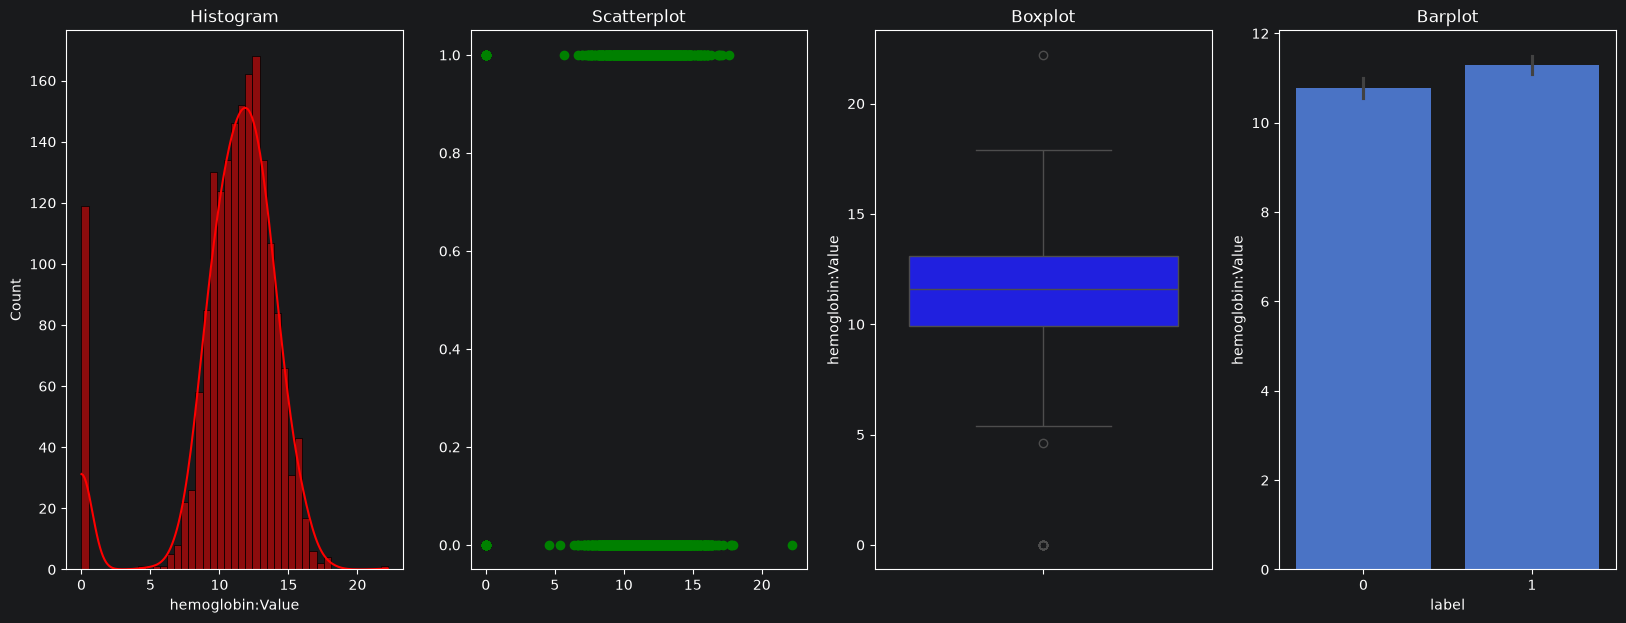

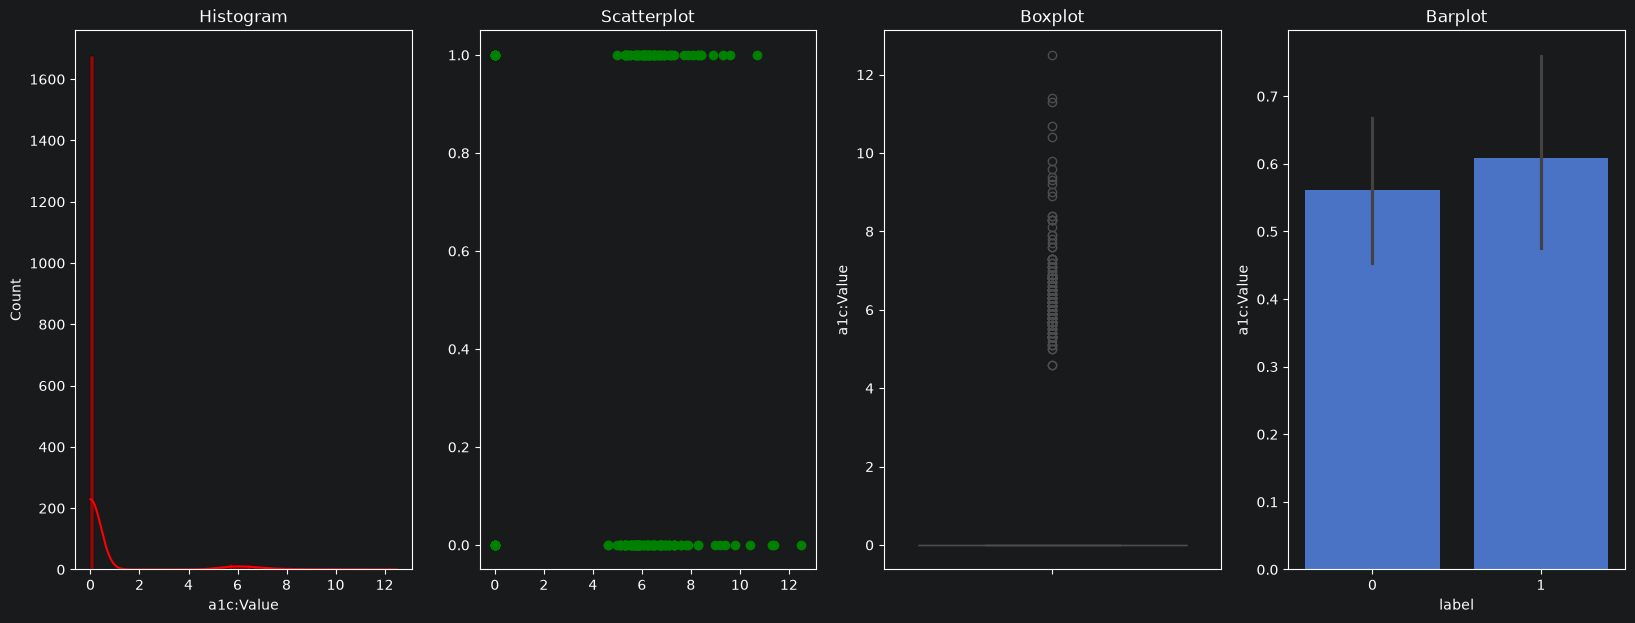

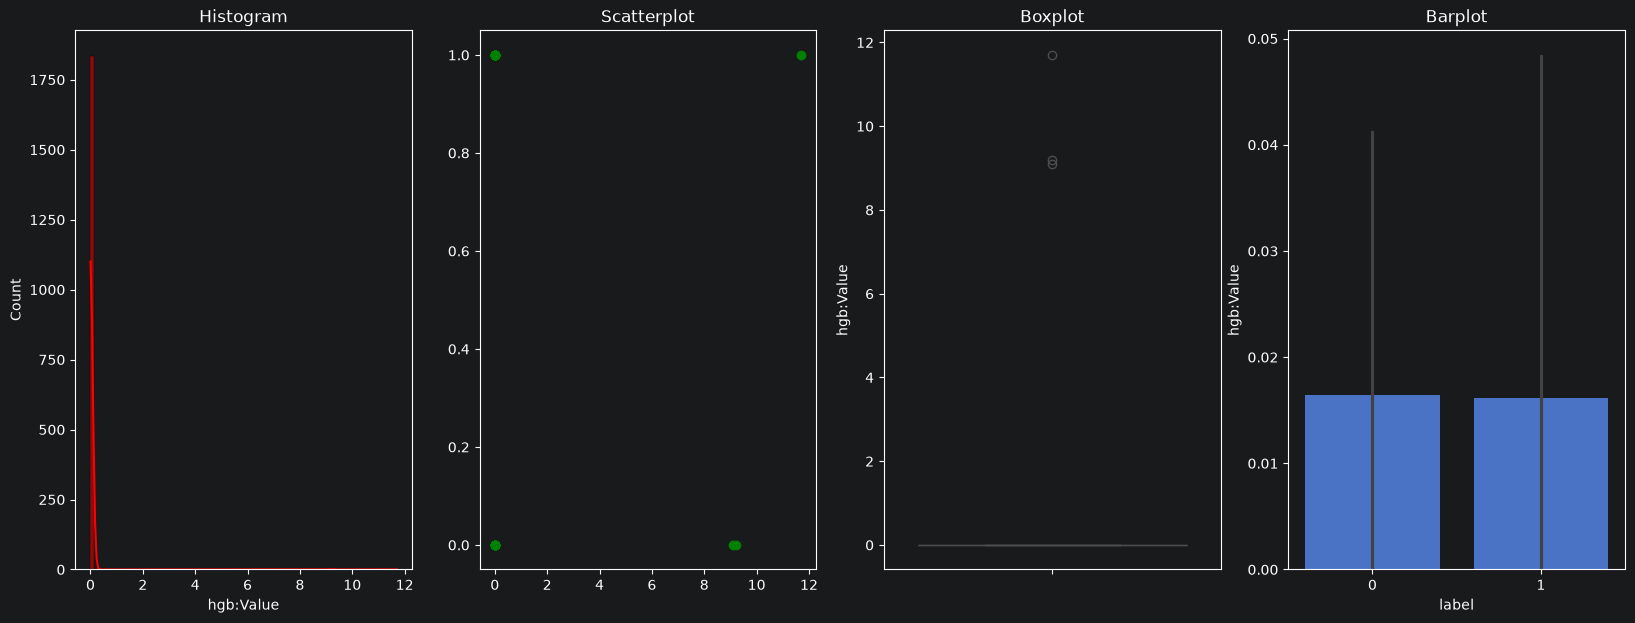

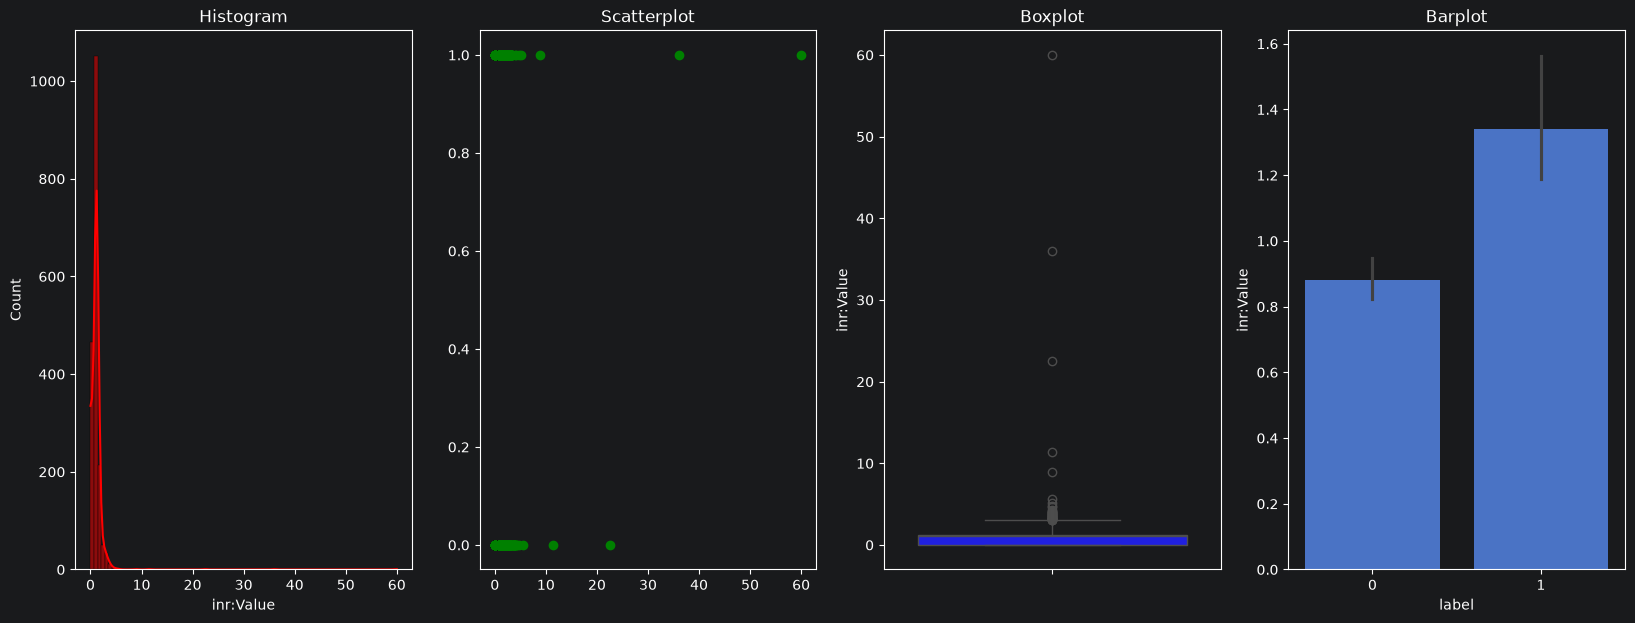

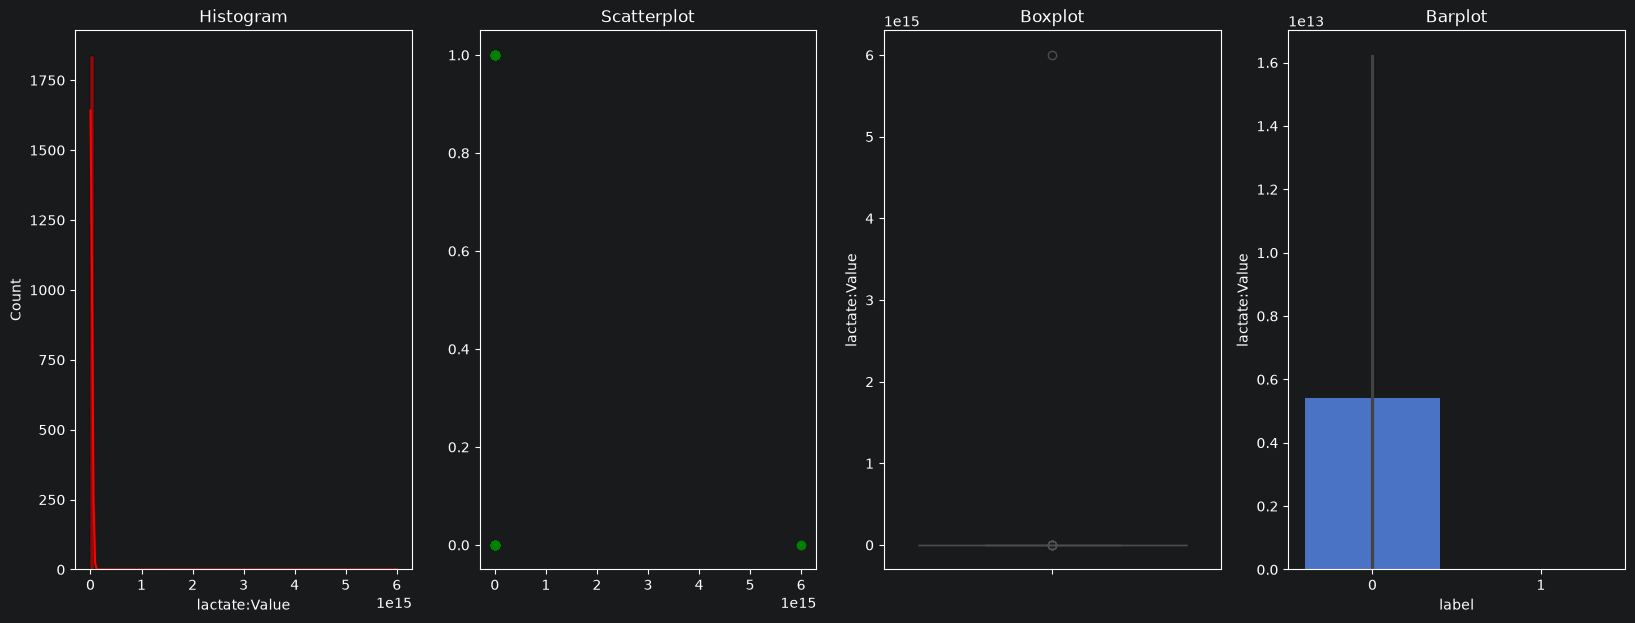

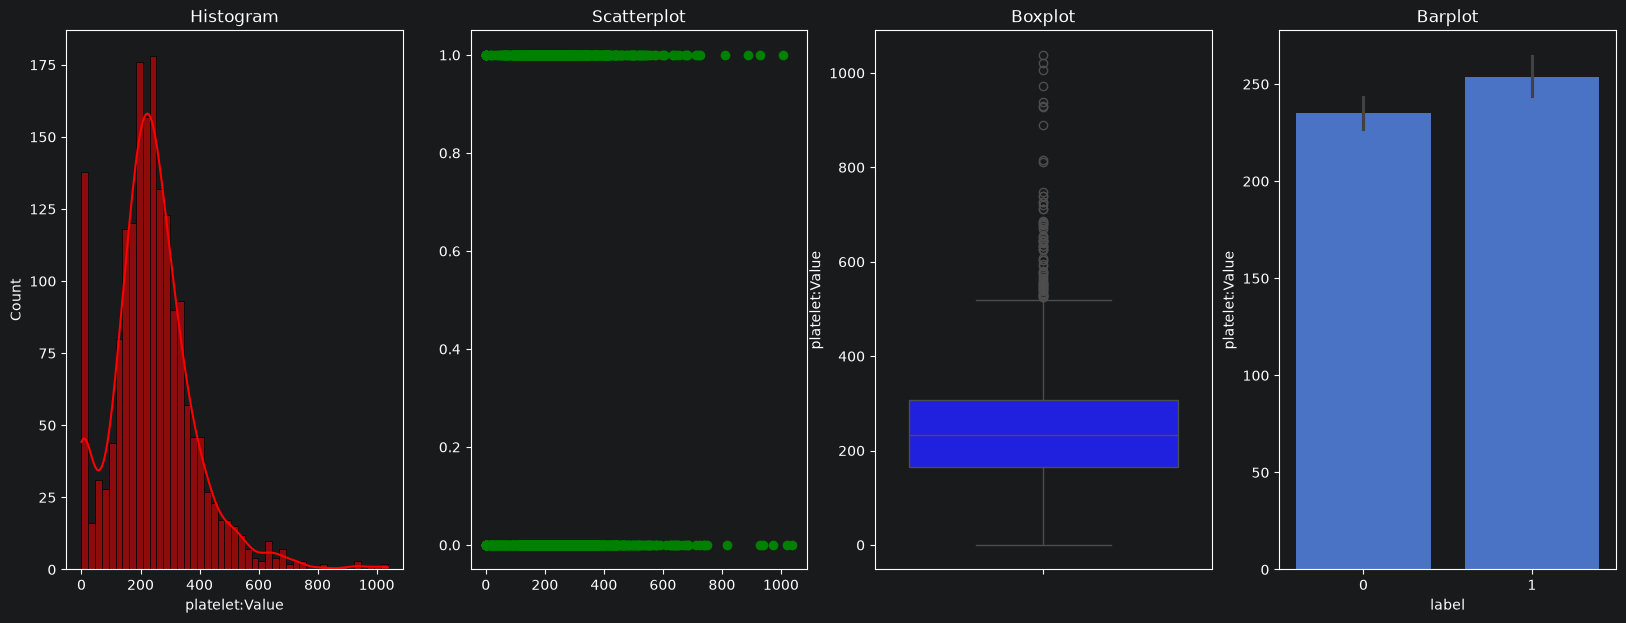

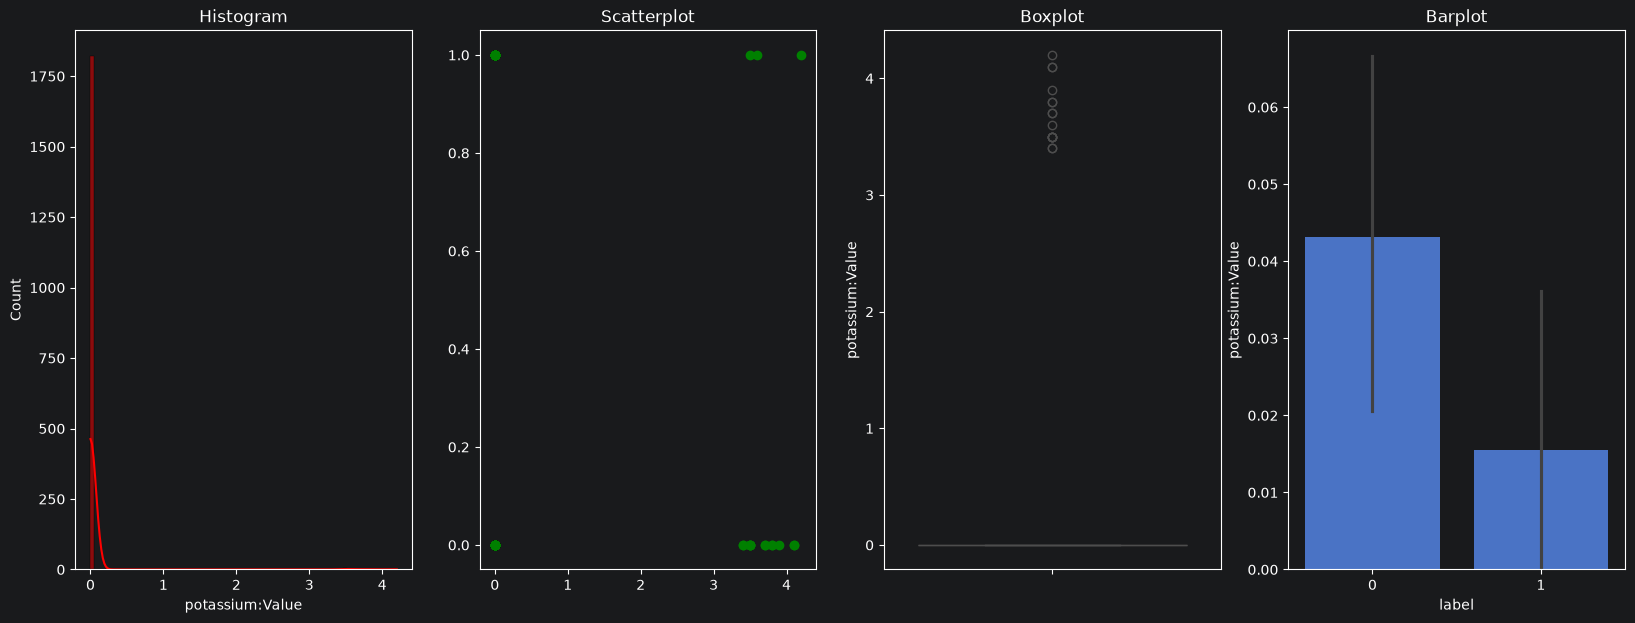

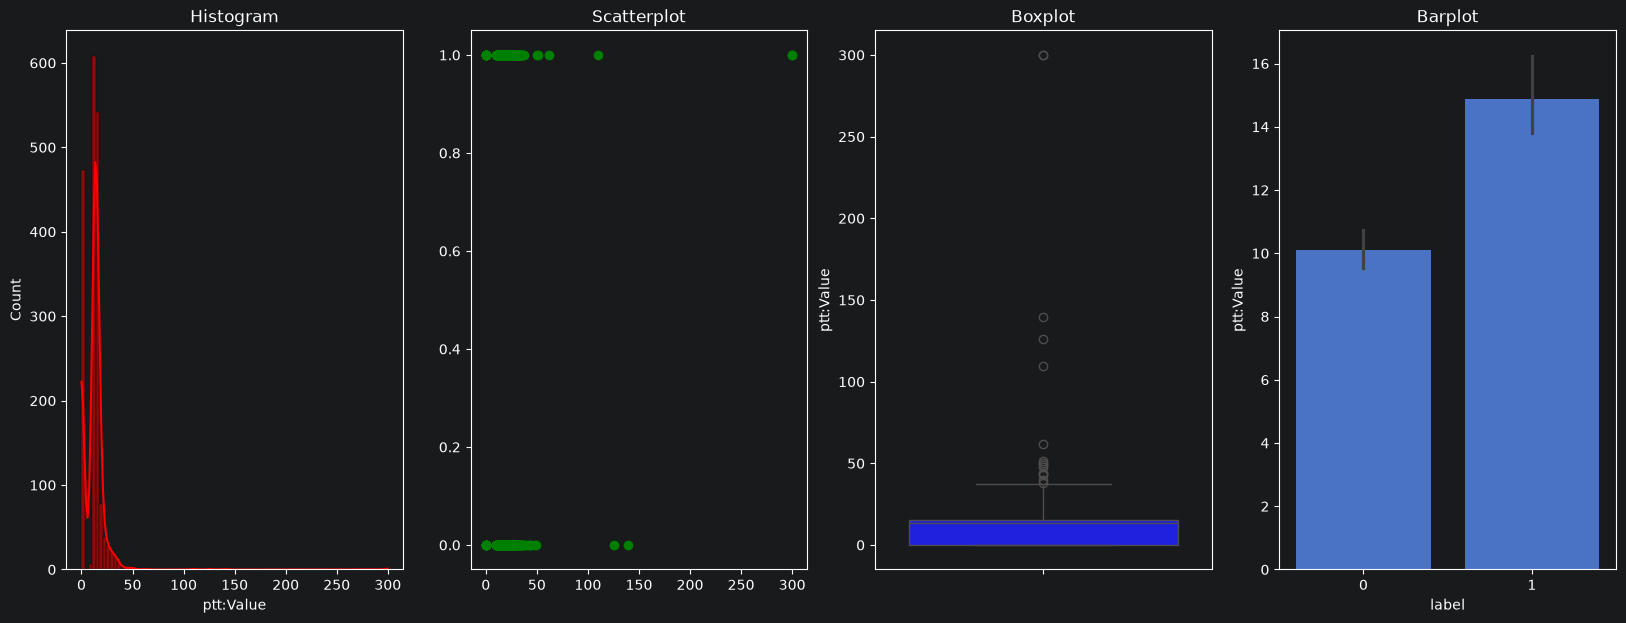

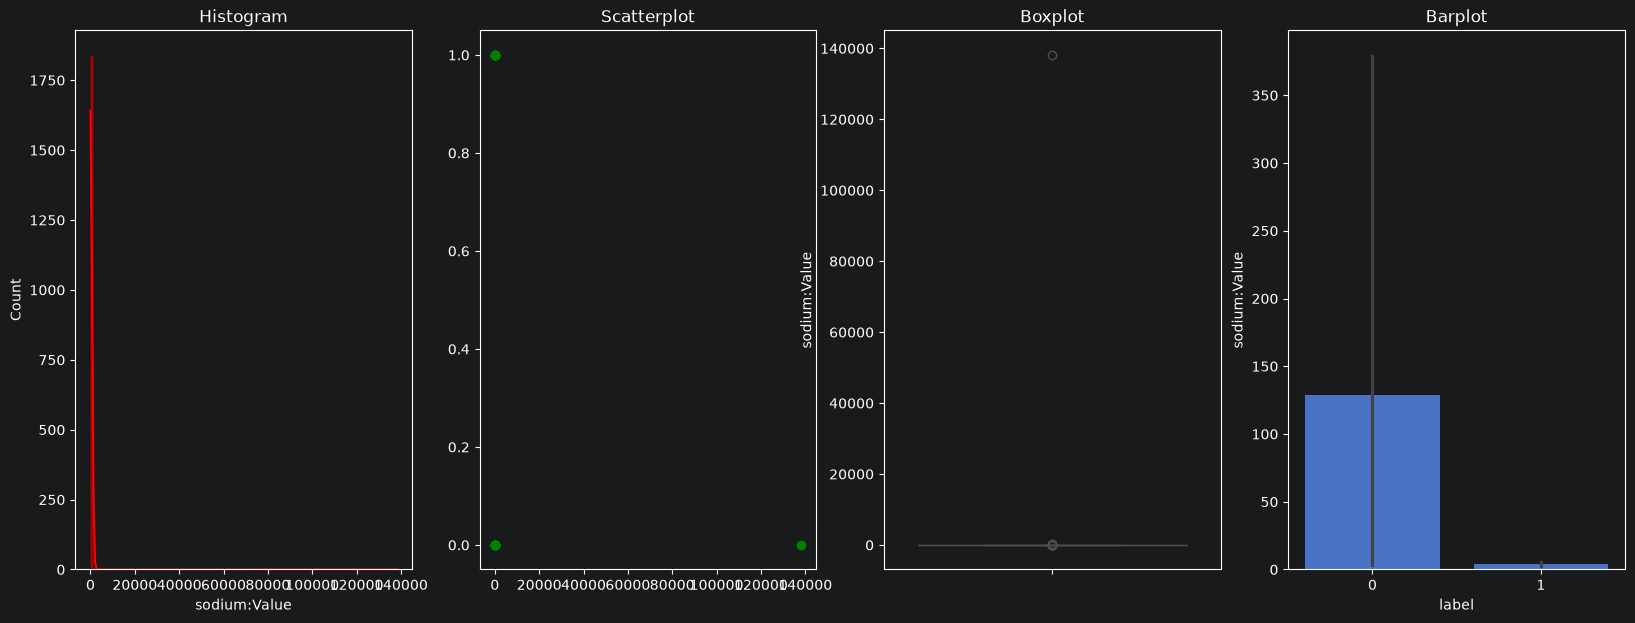

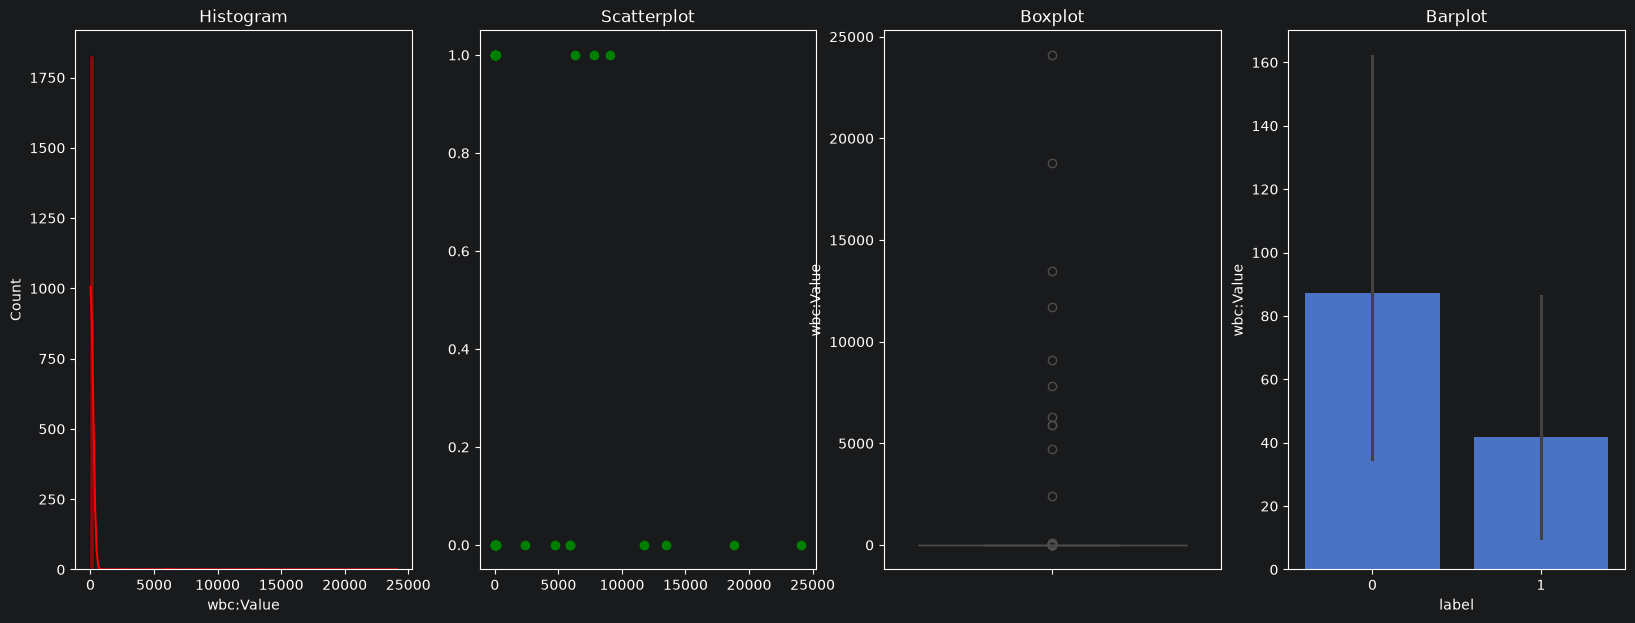

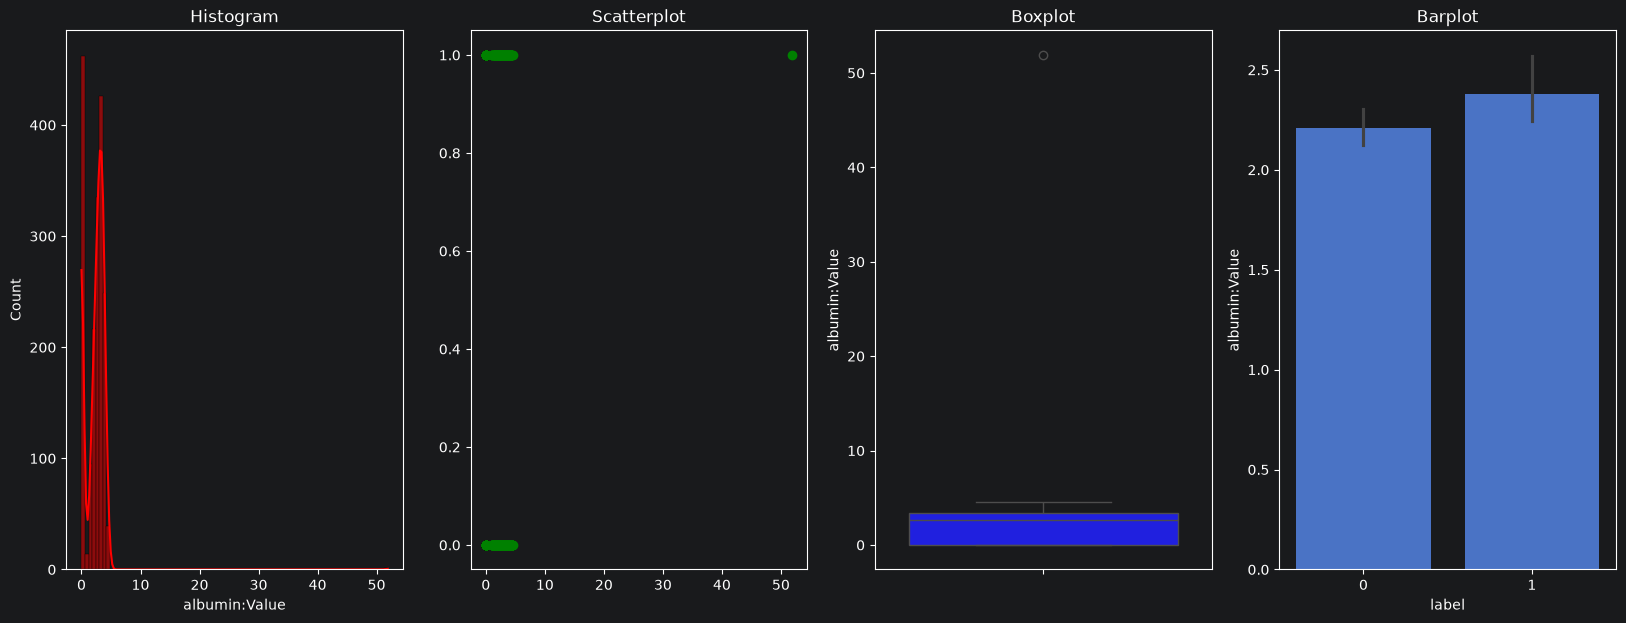

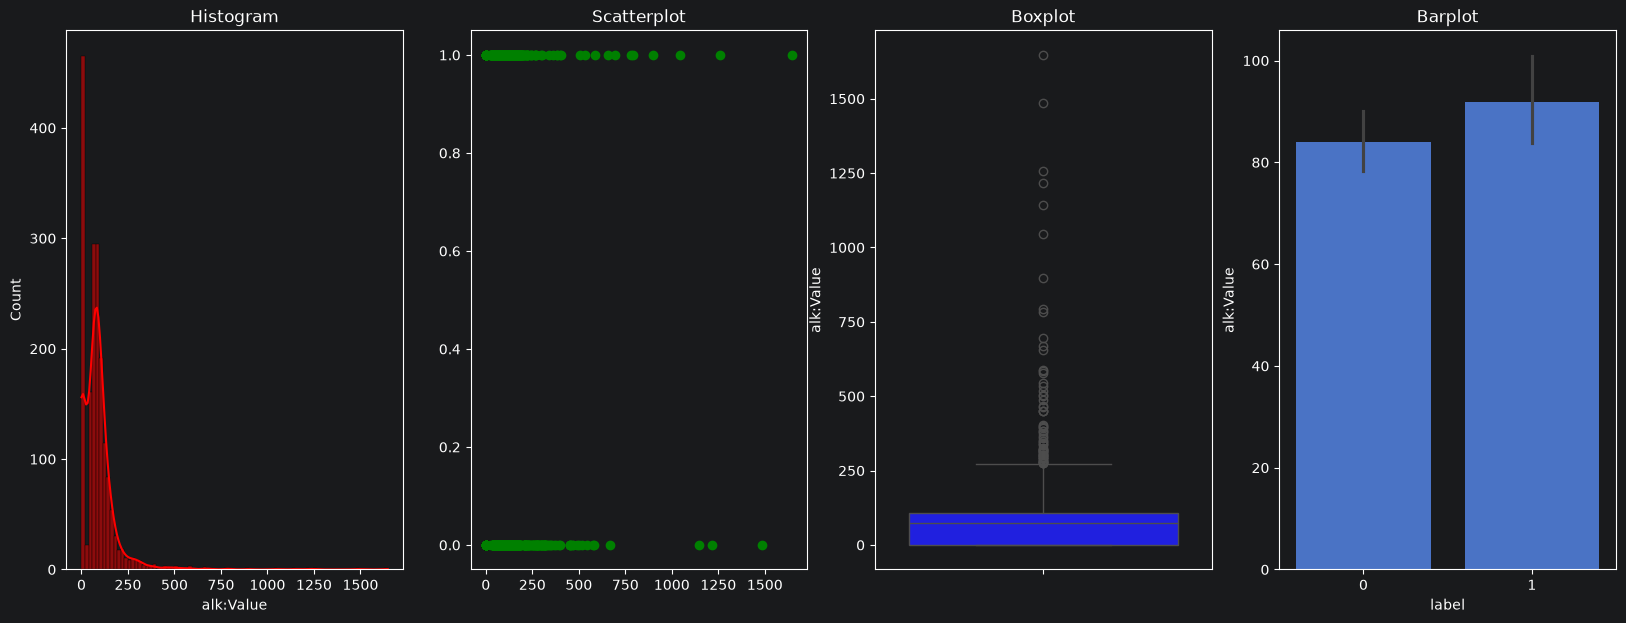

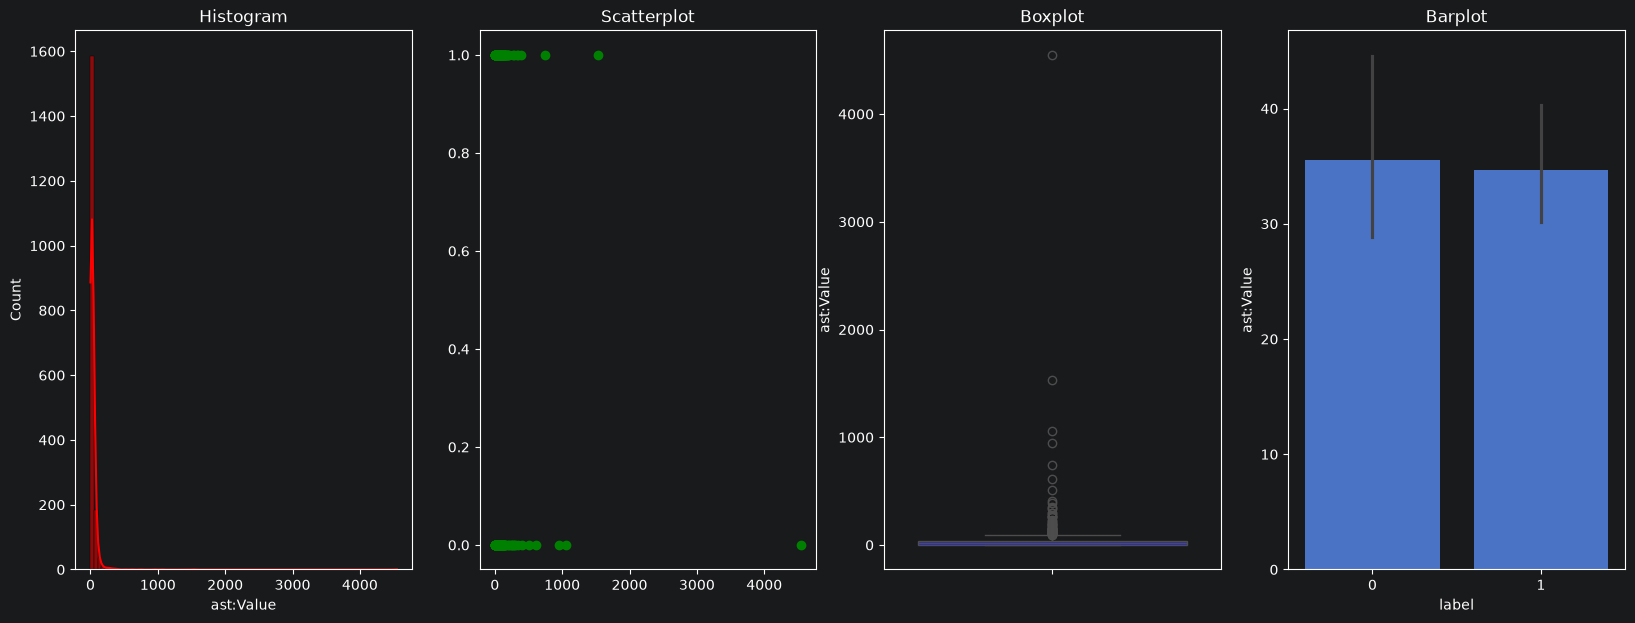

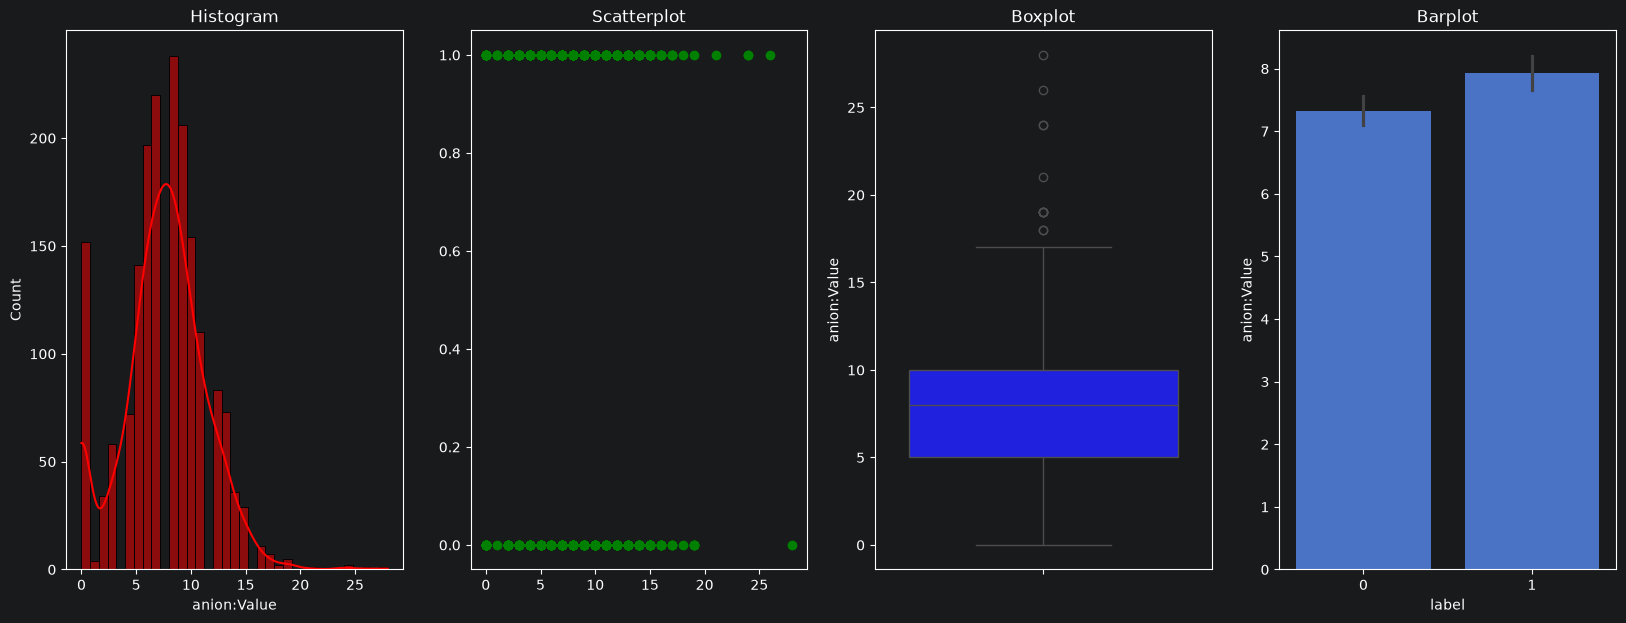

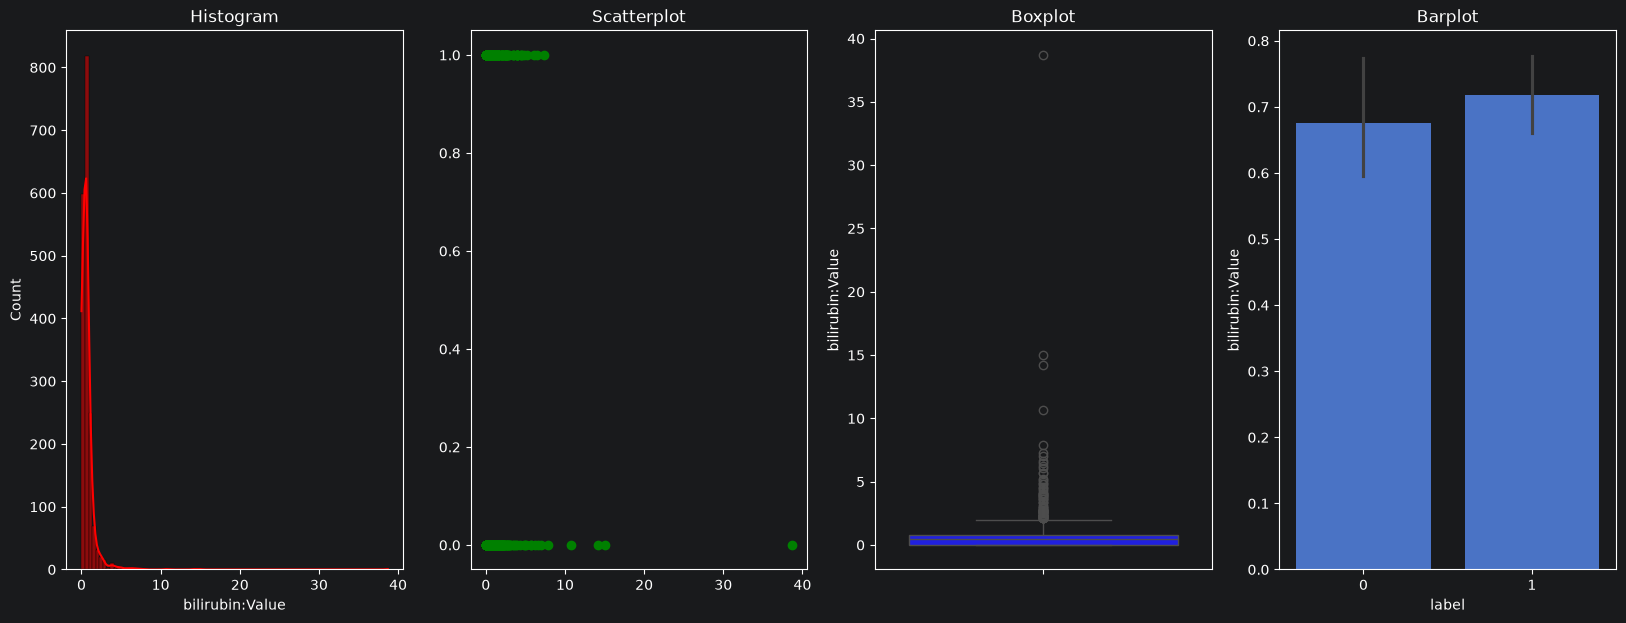

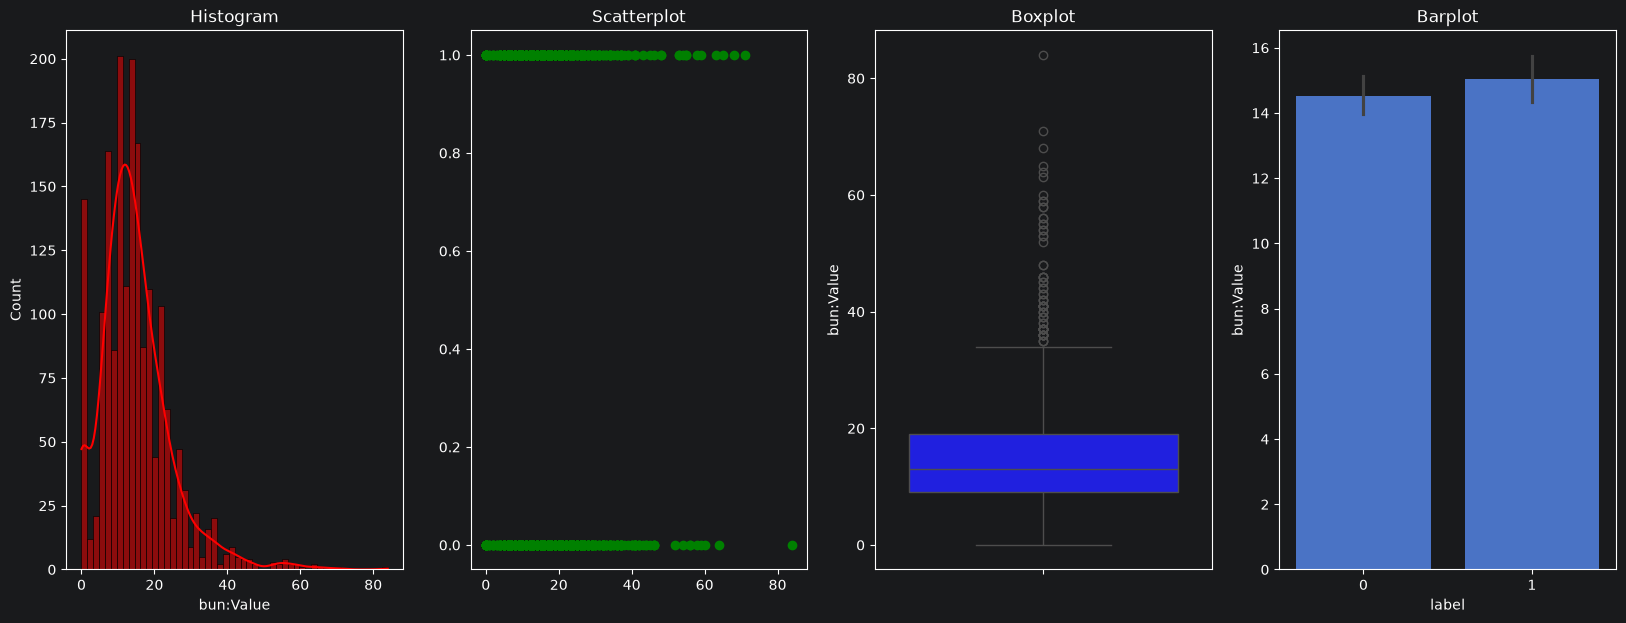

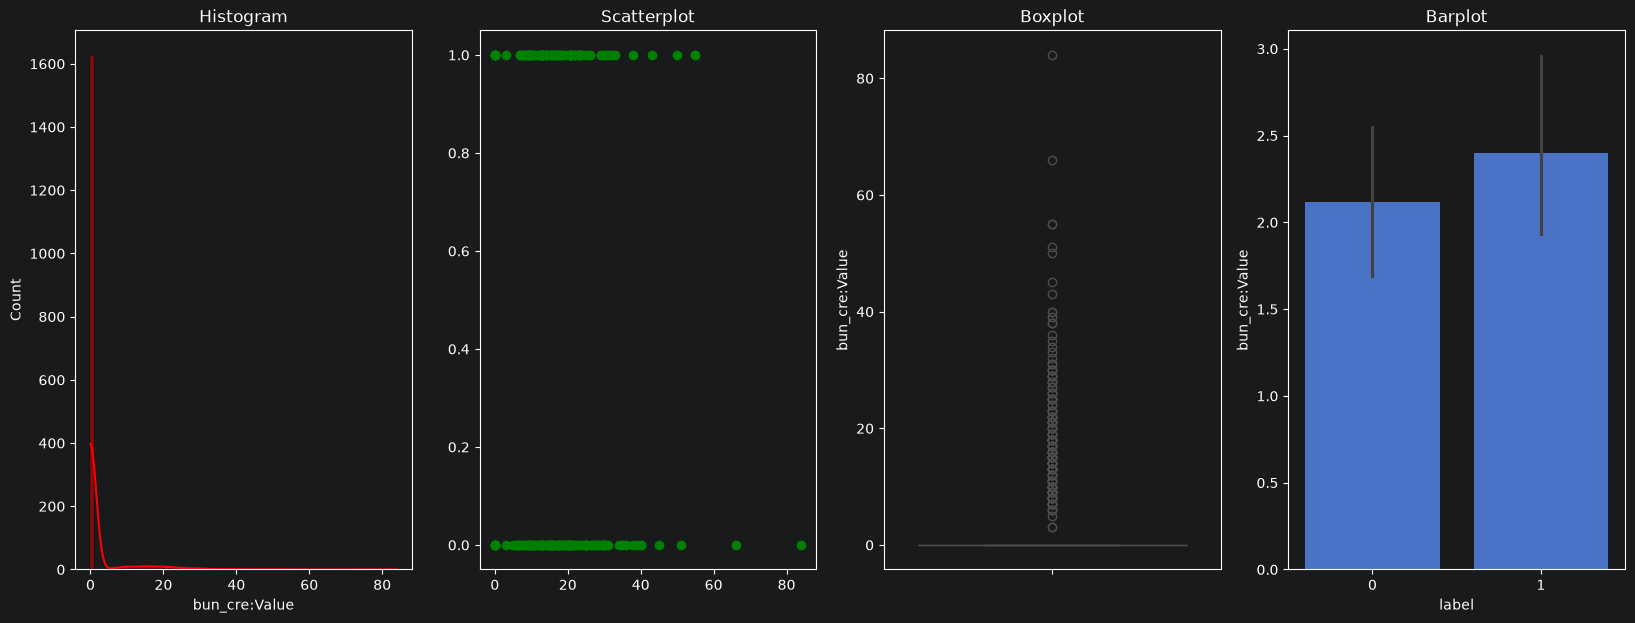

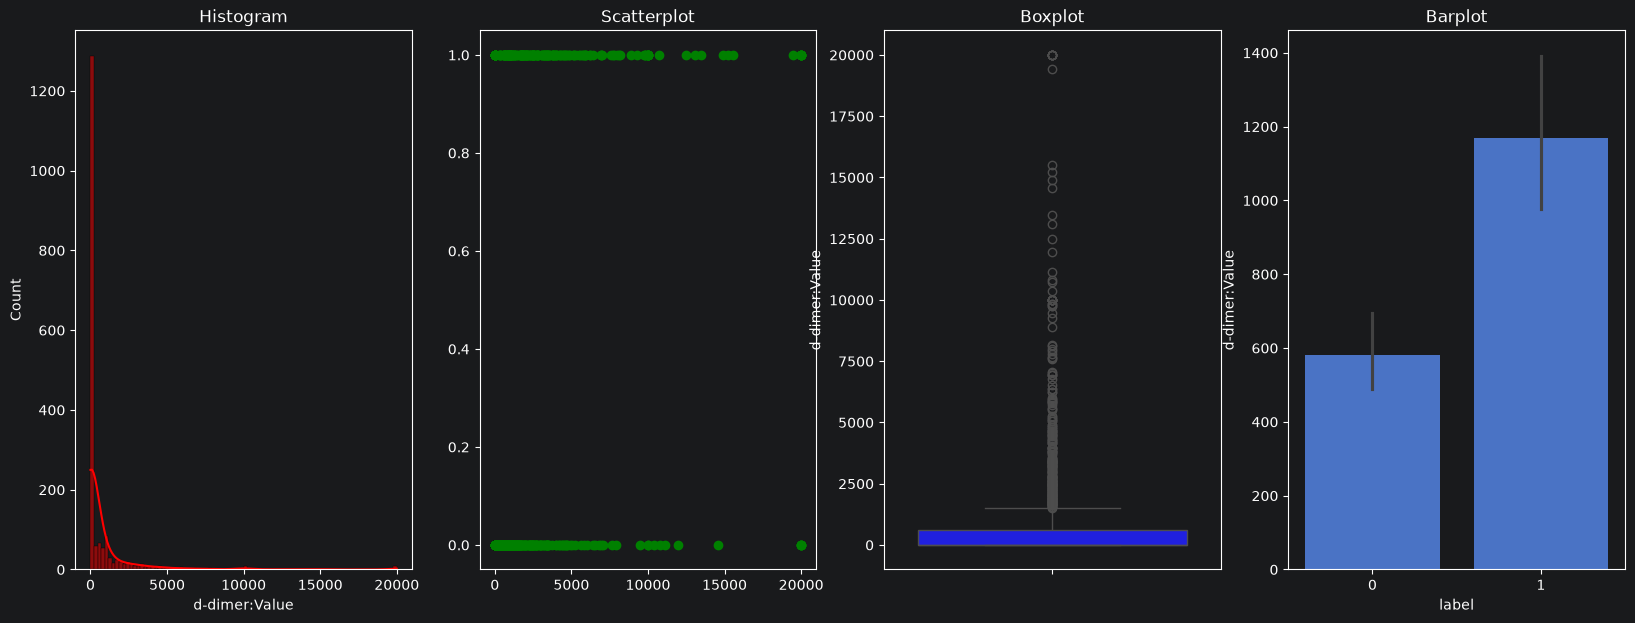

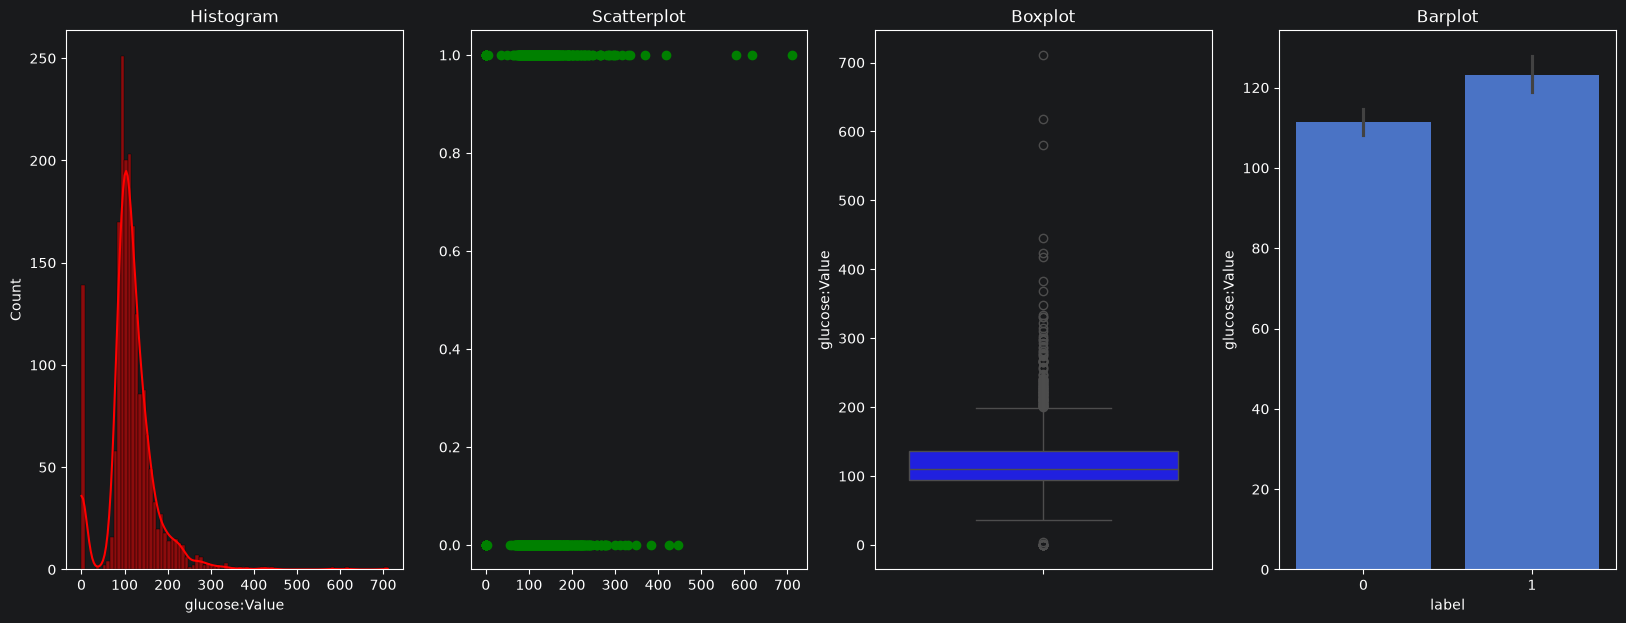

In [45]:
temp_dataset = original_data_labs.merge(original_data_labels[["idx", "label"]], on="idx", how="left", validate='1:1')
for column in ["hemoglobin:Value", "a1c:Value", "hgb:Value", "inr:Value", "lactate:Value", "platelet:Value",
               "potassium:Value", "ptt:Value", "sodium:Value", "wbc:Value", "albumin:Value", "alk:Value", "ast:Value",
               "anion:Value", "bilirubin:Value", "bun:Value", "bun_cre:Value", "d-dimer:Value", "glucose:Value"]:
    diagnostic_plots(temp_dataset, column, "label", False)

## **DATASET-OUT_MED**

The outpatient counterpart of INP_MED -- same 640-drug-category structure,
every column prefixed `Outpatient_` (so it can never collide with
INP_MED's column names once both are merged into the final dataset). Same
reduction policy applies; see the markdown cell right before the filtering
code below for the full reasoning (identical to INP_MED's, with the
outpatient-specific prevalence/correlation numbers).

In [46]:
original_data_out_med = pandas.read_csv("OUT_MED.csv")

In [47]:
original_data_out_med.head()

,Unnamed: 0,"Outpatient_LAXATIVES, LOCAL/RECTAL:Binary",Outpatient_PLATELET AGGREGATION INHIBITORS:Binary,Outpatient_nan:Binary,"Outpatient_NOSE PREPARATIONS, VASOCONSTRICTORS(OTC):Binary","Outpatient_ANALGESIC/ANTIPYRETICS,NON-SALICYLATE:Binary",Outpatient_ANTIHYPERLIPIDEMIC - HMG COA REDUCTASE INHIBITORS:Binary,Outpatient_SELECTIVE SEROTONIN REUPTAKE INHIBITOR (SSRIS):Binary,"Outpatient_VASODILATORS,CORONARY:Binary",Outpatient_ANTIEMETIC/ANTIVERTIGO AGENTS:Binary,...,Outpatient_SELECTIVE SEROTONIN 5-HT2A INVERSE AGONISTS (SSIA):Frequeny,Outpatient_ANTINEOPLASTIC - HEDGEHOG PATHWAY INHIBITOR:Frequeny,Outpatient_ORGAN TRANSPLANTATION PRESERVATION SOLUTIONS:Frequeny,Outpatient_FEEDING DEVICES:Frequeny,"Outpatient_DRUGS TO TX GAUCHER DX-TYPE 1, SUBSTRATE REDUCING:Frequeny","Outpatient_TOPICAL PREPARATIONS,NON-MEDICINAL:Frequeny","Outpatient_ANTI-INFLAMMATORY, INTERLEUKIN-1 BETA BLOCKERS:Frequeny","Outpatient_ACNE AGENTS,SYSTEMIC:Frequeny",idx,split
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,84,test
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2248,test
2,2,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,2271,test
3,3,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1691,test
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3286,test


In [48]:
original_data_out_med.info()

<class 'pandas.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Columns: 1285 entries, Unnamed: 0 to split
dtypes: int64(1284), str(1)
memory usage: 18.5 MB


In [49]:
# Duplicates through patient IDX.
print(original_data_out_med["idx"].value_counts())

idx
291     3
1271    3
1845    3
1959    3
142     2
       ..
1832    1
2487    1
1000    1
2003    1
490     1
Name: count, Length: 1837, dtype: int64


In [50]:
original_data_out_med = original_data_out_med.groupby("idx").first().reset_index().reset_index()
print(original_data_out_med["idx"].value_counts())

idx
0       1
1       1
2       1
3       1
4       1
       ..
3939    1
3940    1
3943    1
3951    1
3957    1
Name: count, Length: 1837, dtype: int64


In [51]:
print(f"Patient count: {original_data_out_med['idx'].count()}")

Patient count: 1837


In [52]:
print("Null values count:")
print(original_data_out_med.isnull().sum())

Null values count:
index                                                                    0
idx                                                                      0
Unnamed: 0                                                               0
Outpatient_LAXATIVES, LOCAL/RECTAL:Binary                                0
Outpatient_PLATELET AGGREGATION INHIBITORS:Binary                        0
                                                                        ..
Outpatient_DRUGS TO TX GAUCHER DX-TYPE 1, SUBSTRATE REDUCING:Frequeny    0
Outpatient_TOPICAL PREPARATIONS,NON-MEDICINAL:Frequeny                   0
Outpatient_ANTI-INFLAMMATORY, INTERLEUKIN-1 BETA BLOCKERS:Frequeny       0
Outpatient_ACNE AGENTS,SYSTEMIC:Frequeny                                 0
split                                                                    0
Length: 1286, dtype: int64


In [53]:
for column in original_data_out_med:
    counts = original_data_out_med[column].value_counts()
    if len(counts) > 1 and ":Binary" in column:
        print(counts)

Outpatient_LAXATIVES, LOCAL/RECTAL:Binary
0    1814
1      23
Name: count, dtype: int64
Outpatient_PLATELET AGGREGATION INHIBITORS:Binary
0    1765
1      72
Name: count, dtype: int64
Outpatient_NOSE PREPARATIONS, VASOCONSTRICTORS(OTC):Binary
0    1835
1       2
Name: count, dtype: int64
Outpatient_ANALGESIC/ANTIPYRETICS,NON-SALICYLATE:Binary
0    1772
1      65
Name: count, dtype: int64
Outpatient_ANTIHYPERLIPIDEMIC - HMG COA REDUCTASE INHIBITORS:Binary
0    1745
1      92
Name: count, dtype: int64
Outpatient_SELECTIVE SEROTONIN REUPTAKE INHIBITOR (SSRIS):Binary
0    1798
1      39
Name: count, dtype: int64
Outpatient_VASODILATORS,CORONARY:Binary
0    1820
1      17
Name: count, dtype: int64
Outpatient_ANTIEMETIC/ANTIVERTIGO AGENTS:Binary
0    1755
1      82
Name: count, dtype: int64
Outpatient_BETA-ADRENERGIC BLOCKING AGENTS:Binary
0    1762
1      75
Name: count, dtype: int64
Outpatient_HEPARIN AND RELATED PREPARATIONS:Binary
0    1730
1     107
Name: count, dtype: int64
Outpatient_

### Column reduction for OUT_MED

Same policy as INP_MED (drop `:Frequeny` + `Outpatient_nan:Binary`, keep
>=1% prevalence `:Binary` columns, force-keep anticoagulants), based on the
same per-column correlation check, run separately on OUT_MED:

- 88% of the 641 `:Binary` columns are under 0.5% prevalence -- even sparser
  than INP_MED, since outpatient prescribing for this inpatient-CT cohort is
  captured less completely.
- The same two anticoagulant classes are again the standout signal:
  - `Outpatient_ANTICOAGULANTS,COUMARIN TYPE:Binary` -- 4.4% prevalence,
    **r = +0.111**.
  - `Outpatient_HEPARIN AND RELATED PREPARATIONS:Binary` -- 5.8%
    prevalence, **r = +0.127** (the strongest correlation among all
    OUT_MED columns checked).

In [54]:
# See the "Column reduction for OUT_MED" notes above for the full rationale.
frequeny_cols = [c for c in original_data_out_med.columns if c.endswith(":Frequeny")]
original_data_out_med = original_data_out_med.drop(columns=frequeny_cols).drop(columns=["Outpatient_nan:Binary"])

percentage_of_ones = original_data_out_med.drop("split", axis=1).drop("Unnamed: 0", axis=1).sum() / len(original_data_out_med)
percentage_of_ones = percentage_of_ones * 100
keep_mask = percentage_of_ones >= 1.0

always_keep = ["Outpatient_HEPARIN AND RELATED PREPARATIONS:Binary", "Outpatient_ANTICOAGULANTS,COUMARIN TYPE:Binary"]
keep_mask.loc[always_keep] = True

original_data_out_med = original_data_out_med.drop("split", axis=1).drop("Unnamed: 0", axis=1).loc[:, keep_mask]

## **CREATING-TRAINING-DATASET**

Assembles the final feature table by left-joining Demographics, ICD, LABS,
INP_MED, and OUT_MED onto the Labels table (`idx`, `label`, `split`), one
merge per table. A few things worth making explicit about this assembly:

- **Merge order doesn't matter functionally**: every merge is a
  `how="left"` join on `idx` with `validate='1:1'`, so each step only ever
  adds columns for the SAME 1837 patients -- it can't change which rows
  exist or their order.
- **`validate='1:1'` is the real safety net**: it makes pandas raise
  immediately if either side of a merge ever has a duplicate `idx` --
  combined with each table's own `.groupby("idx").first()` dedup, this
  guarantees no patient's row can silently fan out into duplicates or pick
  up another patient's data. Verified independently outside pandas too: a
  plain-Python simulation of the entire 6-table join chain confirms every
  one of the 1837 patients' rows carries through all five merges with the
  correct, matching `idx` at every step, and that Demographics/ICD/LABS/
  INP_MED/OUT_MED all cover the exact same 1837 patients as Labels (zero
  missing, zero extra) -- so no merge in this chain can introduce a
  missing-data row or a misattributed one.
- **`index`/`Unnamed: 0` are dropped before merging, not after**: the
  repeated `.groupby("idx").first().reset_index().reset_index()` dedup
  pattern used for ICD/LABS/INP_MED/OUT_MED leaves a meaningless leftover
  `index` column (an artifact of resetting an already-reset index) and,
  for LABS specifically, an un-dropped `Unnamed: 0` (ICD/INP_MED/OUT_MED
  already drop theirs during their own filtering step). Left alone, merging
  more than one such table produces pandas' automatic `_x`/`_y` collision
  suffixes (this is exactly why an earlier version of this notebook had a
  stray `index_x` column in its final feature list) -- dropping them
  explicitly at each merge avoids that.
- **Lab values are cleaned right after the LABS merge** (see "Lab values: plausibility limits and median imputation" below): measured values outside a generous plausibility interval are treated as unusable, and both unusable and unmeasured values (raw placeholder `0.0`) are replaced by the training-split median of the usable measured values; the `:Binary` flag stays as the explicit "was measured" indicator.
- **`idx` is deliberately kept in the final output** (see the save cell
  below) -- not an oversight. It's needed to link these EHR-derived rows
  back to the other RadFusion modalities (e.g. the CT imaging) by patient.
  **It must be dropped again before training a model on this data** -- it's
  a patient identifier, not a feature.
- **Known train/val/test limitation, inherited from RadFusion's own
  `split` column** (not introduced by this notebook): the PE-positive rate
  is **34.9% in train, 56.0% in val, 57.9% in test** -- a genuine
  label-prior shift between splits, not just class imbalance. A model
  trained under a 35% prior will have probabilities that are systematically
  miscalibrated against the ~58%-prior val/test sets, and any
  threshold-based metric (accuracy, F1, a balanced sensitivity/specificity
  cut-off) computed on val/test should be read with this in mind. Whether
  to keep RadFusion's official split (for comparability with prior
  published RadFusion benchmarks) or pool and re-stratify (for
  methodological consistency with the arrhythmia/readmit datasets in this
  project, both of which use matched train/test prevalence) is a decision
  for the paper, not something resolved here.

At the time of writing the assembled table has **295 feature columns** (3 demographics + 92 ICD + 42 LABS + 107 INP_MED + 51 OUT_MED), i.e. 298 columns including `idx`, `label` and `split`; the "Features count" cell below prints the actual number. The leak-free variant written at the end (see "Possible-leakage screen and the leak-free variant") has 293 feature columns.


In [55]:
# Get patient id and the target feature.
original_data = original_data_labels[["idx", "label", "split"]].copy()
original_data.head()

,idx,label,split
0,1436,0,train
1,1880,1,train
2,2738,0,val
3,2883,0,train
4,2302,1,train


In [56]:
# Merge some of the DEMOGRAPHICS features.
original_data = original_data.merge(original_data_demographics[["idx", "Female", "current_age_yrs", "SMOKER_Y"]],
                                    on="idx", how="left", validate='1:1')

In [57]:
# Merge ICD features (index dropped -- see notes above).
original_data = original_data.merge(
    original_data_icd.drop(columns=["index"]), on="idx", how="left", validate='1:1')

In [58]:
# Merge LABS features (nan:*/index/Unnamed: 0 dropped -- see notes above).
original_data = original_data.merge(
    original_data_labs.drop(columns=["split", "nan:Value", "nan:Binary", "index", "Unnamed: 0"]),
    on="idx", how="left", validate='1:1')

### Lab values: plausibility limits and median imputation (the `:Binary` flag is kept)

Two different problems sit in the raw `:Value` columns; both are handled here, in this order.

**Problem 1 -- impossible measured values.** Some *measured* values are not physiologically possible or are written in another unit than the rest of their column: `creatinine` reaches 2.7e16 (12 values from 7e14 up, plus 22 values of 57-97 that look like normal creatinine in umol/L instead of mg/dL), `lactate` has 8 values from 171 up to 6e15 against a median of 1.6 mmol/L, `wbc` has 11 values of 2400-24100 (cells/uL instead of 10^3 cells/uL), and there is one `sodium` of 138 100, one `albumin` of 51.9 (g/L instead of g/dL), two INR values of 36 and 60 and three glucose values of 1-4 mg/dL. Left in, they wreck the column: the training standard deviation of `creatinine:Value` is 7.8e14 and that of `lactate:Value` 1.5e14, so after the standardisation that every model applies these columns are constants for all but a handful of patients, and any noise proportional to a column's standard deviation is astronomically large in raw units.

**What is done about it.** Every lab has a plausibility interval (`LAB_PLAUSIBLE_RANGE` in the code cell below, in the presumed units of the raw file). A measured value outside its interval is **unusable**: 60 values in 7 of the 21 labs (45 in the training split, 9 in validation, 6 in test).
- The intervals are deliberately generous. They only catch impossible values and unit/decimal errors; real extremes stay (AST up to 4548, glucose 711, INR 22.5, the PTT ceiling of 300 s that 2 values sit on, the D-dimer ceiling of 20 000 that 10 values sit on). They are **not** clinical reference ranges. They were chosen from the data's own tails -- in every affected column a clear gap separates the plausible cluster from the excluded values (creatinine: nothing between 11.2 and 57) -- and should be confirmed by a clinician.
- Unusable values are **not clipped** to the edge of the interval: a garbage 2.7e16 clipped to 30 would become an extreme but believable value (renal failure), and a creatinine of 88 (a normal value in umol/L) clipped to 30 would turn a healthy patient into an extreme one. They are not converted either (divide by 88.4, by 1000): the unit of an individual value cannot be verified. They are treated like a missing value instead (Problem 2).
- The `:Binary` flag is **not** changed for an unusable value: the test was ordered, and that is informative in itself.

**Problem 2 -- the placeholder for missing values.** In the raw file `:Value` is `0.0` whenever the test was not drawn (`:Binary == 0`). That is a placeholder, not a measurement: 0 is not a physiological value for any of these tests and sits far from the real ones (albumin ~3, platelets ~240, d-dimer ~1200). Left as it is, the placeholder contaminates the column: its marginal correlation with the outcome mixes two different effects -- the effect of the *value* and the effect of *being measured at all*. Being measured is itself informative here (ordering INR/PTT reflects clinical suspicion / an anticoagulation work-up: the `:Binary` flag alone correlates up to +0.28 with PE, while the value among measured patients is close to uncorrelated with PE for most tests). A logistic regression that contains both the flag and the value estimates the *within-measured* slope for the value, so the coefficient and the zero-polluted marginal correlation can disagree in sign purely because of the representation. Checked on the train+validation patients: for **6 of the 18** testable lab tests (those with at least 20 measured patients) the sign of corr(`:Value`, PE) with the zeros in disagrees with the sign among the measured patients -- an artificial sign inconsistency baked into the data, which is exactly what MORSE's sign-consistency objective would (wrongly) penalise.

**What is done about it.** For every test, the `:Value` of every patient whose value is *not usable* -- not drawn (`:Binary == 0`) or unusable (Problem 1) -- is replaced by the median of the **usable measured** values in the **training** split (fitted on `split == "train"` only, so nothing from val/test leaks into the features). The `:Binary` flag stays as the explicit "was measured" indicator, so the two columns carry separate information: *whether* the test was drawn and *what it showed*.

**Effect (train + validation, verified on the real files).**
- After both steps the sign disagreement drops from 6/18 to 2/18; the two remaining ones (bilirubin +0.002 vs -0.011, INR +0.016 vs -0.010, each compared with the correlation among the usable measured patients) are correlations indistinguishable from zero.
- The standard deviations become sane: `creatinine:Value` 7.8e14 -> 0.84, `lactate:Value` 1.5e14 -> 0.74, `wbc:Value` 759 -> 6.4, `sodium:Value` 3400 -> 0.75, `inr:Value` 1.85 -> 0.77, `albumin:Value` 1.36 -> 0.64.
- The lab values stay weak predictors: the largest |correlation| of any `:Value` column with the PE label is 0.15 (D-dimer), before and after. Most of the laboratory information in this cohort sits in the `:Binary` "was it ordered" flags.

**Details worth knowing.**
- "Unmeasured" is defined by the `:Binary` flag, never by `Value == 0`: `anion` has 4 patients with `:Binary == 1` and a measured value of exactly `0.0`, which is plausible and kept.
- The medians of rare tests rest on very few patients (`hgb`: 3 measured patients in the training split; `calcium` and `potassium`: 14 each). After imputation those columns are nearly constant and effectively act as their `:Binary` flag.
- Median imputation shrinks the variance of a column (the unmeasured and unusable patients all get the same value). That is intended: missingness here is *informative* (clinical work-up), so it is carried by the flag instead of being spread over the value.
- The values are not log-transformed although several labs are skewed (d-dimer, INR, PTT, creatinine); that is a separate representation choice.

In [59]:
# Lab values: plausibility limits, then median imputation (see the notes above).
# The :Binary flag stays as the explicit "was measured" indicator. Medians are
# fitted on the training split only.

# (low, high) plausibility interval per lab test, inclusive, in the presumed units of the raw
# file (inferred from the typical values). Deliberately generous: only impossible values and
# unit / decimal errors are caught. These are NOT clinical reference ranges -- please have a
# clinician confirm them.
LAB_PLAUSIBLE_RANGE: dict[str, tuple[float, float]] = {
    "albumin":    (0.5, 7.0),       # g/dL
    "alk":        (5, 5000),        # U/L
    "ast":        (1, 20000),       # U/L
    "anion":      (-10, 60),        # mmol/L
    "bilirubin":  (0.05, 80),       # mg/dL
    "bun":        (1, 300),         # mg/dL
    "bun_cre":    (1, 200),         # ratio
    "calcium":    (3, 20),          # mg/dL
    "creatinine": (0.1, 30),        # mg/dL
    "d-dimer":    (1, 100000),      # ng/mL
    "glucose":    (10, 2000),       # mg/dL
    "hemoglobin": (2, 25),          # g/dL
    "a1c":        (3, 20),          # %
    "hgb":        (2, 25),          # g/dL
    "inr":        (0.5, 30),        # ratio
    "lactate":    (0.1, 30),        # mmol/L
    "platelet":   (1, 2500),        # 10^3/uL
    "potassium":  (1.5, 10),        # mmol/L
    "ptt":        (5, 400),         # s
    "sodium":     (100, 180),       # mmol/L
    "wbc":        (0.05, 500),      # 10^3/uL
}

lab_tests = [c[: -len(":Value")] for c in original_data.columns if c.endswith(":Value")]
out_of_sync = sorted(set(lab_tests) ^ set(LAB_PLAUSIBLE_RANGE))
assert not out_of_sync, f"LAB_PLAUSIBLE_RANGE and the lab columns disagree about: {out_of_sync}"
is_train = original_data["split"] == "train"

n_unusable_total = 0
for lab_test in lab_tests:
    low, high = LAB_PLAUSIBLE_RANGE[lab_test]
    value = original_data[f"{lab_test}:Value"]
    measured = original_data[f"{lab_test}:Binary"] == 1
    usable = measured & value.between(low, high)          # measured AND plausible
    train_median = value[is_train & usable].median()
    assert not pandas.isna(train_median), \
        f"{lab_test}: no usable measured value in the training split to take a median from"
    original_data.loc[~usable, f"{lab_test}:Value"] = train_median
    n_unusable = int((measured & ~usable).sum())
    n_unusable_total += n_unusable
    print(f"{lab_test:12s} unmeasured {int((~measured).sum()):4d}  unusable {n_unusable:3d}  "
          f"-> {int((~usable).sum()):4d} values set to the training median {train_median:g}")
print(f"\nUnusable measured values replaced in total: {n_unusable_total}")

albumin      unmeasured  462  unusable   1  ->  463 values set to the training median 3.1
alk          unmeasured  464  unusable   0  ->  464 values set to the training median 89
ast          unmeasured  464  unusable   0  ->  464 values set to the training median 30
anion        unmeasured  148  unusable   0  ->  148 values set to the training median 8
bilirubin    unmeasured  468  unusable   0  ->  468 values set to the training median 0.6
bun          unmeasured  140  unusable   0  ->  140 values set to the training median 14
bun_cre      unmeasured 1624  unusable   0  -> 1624 values set to the training median 17
calcium      unmeasured 1819  unusable   0  -> 1819 values set to the training median 8.7
creatinine   unmeasured  102  unusable  34  ->  136 values set to the training median 0.9
d-dimer      unmeasured 1266  unusable   0  -> 1266 values set to the training median 1174
glucose      unmeasured  136  unusable   3  ->  139 values set to the training median 113
hemoglobin   un

In [60]:
# Merge INP_MED (inpatient medication) features (index dropped -- see notes above).
original_data = original_data.merge(
    original_data_inp_med.drop(columns=["index"]),
    on="idx", how="left", validate='1:1')

In [61]:
# Merge OUT_MED (outpatient medication) features (index dropped -- see notes above).
original_data = original_data.merge(
    original_data_out_med.drop(columns=["index"]),
    on="idx", how="left", validate='1:1')

In [62]:
# Defensive: nothing should be left named "Unnamed: 0" given the drops
# above, but keep this tolerant (errors="ignore") as a safety net.
original_data = original_data.drop(columns=["Unnamed: 0"], errors="ignore")

In [63]:
# Final data-quality gate before saving: confirm the merges above didn't
# introduce any missing values (they shouldn't -- every source table
# covers the exact same 1837 patients as Labels, verified above).
print("Null values count (final merged dataset):")
print(original_data.isnull().sum())

Null values count (final merged dataset):
idx                                                    0
label                                                  0
split                                                  0
Female                                                 0
current_age_yrs                                        0
                                                      ..
Outpatient_THYROID HORMONES:Binary                     0
Outpatient_ANTICONVULSANTS:Binary                      0
Outpatient_ANTI-ANXIETY DRUGS:Binary                   0
Outpatient_ANTIHYPERGLYCEMIC, BIGUANIDE TYPE:Binary    0
Outpatient_SKELETAL MUSCLE RELAXANTS:Binary            0
Length: 298, dtype: int64


### Possible-leakage screen and the leak-free variant

**Why.** A feature that (nearly) encodes the outcome makes every model look excellent for the wrong reason and turns feature selection into "find that one feature". This screen looks for such features before the table is saved. For every feature it computes the single-feature ROC-AUC against the PE label on the **train + validation** rows only (the test split is deliberately not used, so the decision about a feature never depends on test labels); for binary features it also prints how often the flag is set among PE-positive and PE-negative patients.

**What it finds (1647 train+validation patients, 616 PE-positive, 295 features screened).** Exactly one feature stands out: `DISEASES OF PULMONARY CIRCULATION:presence` -- the ICD block that contains pulmonary embolism itself. Alone it reaches ROC-AUC 0.883: the flag is set for 93.0% of the PE-positive and 16.4% of the PE-negative patients (prevalence 45.1%). The runner-up is far behind (`DISEASES OF VEINS AND LYMPHATICS, AND OTHER DISEASES OF CIRCULATORY SYSTEM:presence`, 0.664, then `ptt:Binary` 0.626 and `inr:Binary` 0.624; the best continuous column is `d-dimer:Value` at 0.600). A 93% carrying rate among PE patients is not plausible as *prior* history, so these ICD codes probably include the index encounter -- the PE diagnosis itself, recorded after (or because of) the very finding the model is asked to predict. The medication tables do not show the matching treatment signal (inpatient heparin is set for 24.2% of the PE-positive and 20.3% of the PE-negative patients), which suggests that they are restricted to the time before the CT and the ICD table is not.

**What this notebook cannot decide.** Whether the ICD table is restricted to the time before the imaging study is a fact about how RadFusion was built -- check its documentation. The notebook therefore *flags and offers a switch*, it does not silently remove anything.

**The switch.** `POSSIBLE_LEAK_FEATURES` (code cell below) lists the columns to exclude. The notebook writes BOTH the full feature table (`rad_fusion_*_modified.csv`, unchanged) and a leak-free variant without those columns (`rad_fusion_*_noleak_modified.csv`), so that results can be reported for both. Two columns are listed: the screen hit above, and the veins/lymphatics category, which the screen does NOT flag (0.664) but which contains deep-vein-thrombosis codes that are typically assigned in the same encounter as the PE diagnosis -- excluded as a conservative choice; remove it from the list if the ICD window is confirmed to end before the CT. The code warns if a feature that is not in the list crosses the screen threshold. To train on the leak-free files, point the training notebook at the `_noleak` CSVs and make sure its column whitelist no longer names the two dropped columns (or simply drop `idx` instead of listing columns).

In [64]:
# Possible-leakage screen (see the notes above). Uses the train + validation rows only.
POSSIBLE_LEAK_FEATURES: list[str] = [
    # Screen hit (single-feature ROC-AUC 0.88): the ICD block that contains pulmonary embolism itself.
    "DISEASES OF PULMONARY CIRCULATION:presence",
    # Not a screen hit (0.66), excluded as a conservative choice: deep-vein-thrombosis codes are
    # typically assigned in the same encounter as the PE diagnosis.
    "DISEASES OF VEINS AND LYMPHATICS, AND OTHER DISEASES OF CIRCULATORY SYSTEM:presence",
]
LEAK_SCREEN_ROC_AUC: float = 0.80   # a single feature at or above this ROC-AUC is reported as suspicious

unknown = [c for c in POSSIBLE_LEAK_FEATURES if c not in original_data.columns]
assert not unknown, f"POSSIBLE_LEAK_FEATURES not found in the assembled table: {unknown}"

feature_columns = [c for c in original_data.columns if c not in ("idx", "label", "split")]
fit_rows = original_data[original_data["split"] != "test"]
y_fit = fit_rows["label"].astype(int)
n_pos = int((y_fit == 1).sum())
n_neg = len(y_fit) - n_pos

screen_rows = []
for column in feature_columns:
    x = fit_rows[column]
    ranks = x.rank(method="average")
    auc = (ranks[y_fit == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)   # Mann-Whitney U / (n_pos * n_neg)
    is_binary = set(x.unique()) <= {0, 1}
    screen_rows.append({
        "feature": column,
        "single_feature_roc_auc": max(auc, 1 - auc),      # orientation-free
        "prevalence": x.mean() if is_binary else float("nan"),
        "P(flag | PE)": x[y_fit == 1].mean() if is_binary else float("nan"),
        "P(flag | no PE)": x[y_fit == 0].mean() if is_binary else float("nan"),
    })
leak_screen = (pandas.DataFrame(screen_rows)
               .sort_values("single_feature_roc_auc", ascending=False).reset_index(drop=True))

print(f"Screened {len(leak_screen)} features on {len(fit_rows)} train+validation patients ({n_pos} PE-positive):")
print(leak_screen.head(10).to_string(float_format=lambda v: f"{v:.3f}"))

hits = leak_screen.loc[leak_screen["single_feature_roc_auc"] >= LEAK_SCREEN_ROC_AUC, "feature"].tolist()
not_listed = [c for c in hits if c not in POSSIBLE_LEAK_FEATURES]
print(f"\nScreen hits (single-feature ROC-AUC >= {LEAK_SCREEN_ROC_AUC}): {hits}")
if not_listed:
    print(f"WARNING: screen hits that are NOT in POSSIBLE_LEAK_FEATURES -- add them or justify keeping them: {not_listed}")
print(f"Excluded from the leak-free variant: {POSSIBLE_LEAK_FEATURES}")

leak_free_data = original_data.drop(columns=POSSIBLE_LEAK_FEATURES)
print(f"Feature columns: full {len(feature_columns)}, leak-free {len(feature_columns) - len(POSSIBLE_LEAK_FEATURES)}")

Screened 295 features on 1647 train+validation patients (616 PE-positive):
                                                                               feature  single_feature_roc_auc  prevalence  P(flag | PE)  P(flag | no PE)
0                                           DISEASES OF PULMONARY CIRCULATION:presence                   0.883       0.451         0.930            0.164
1  DISEASES OF VEINS AND LYMPHATICS, AND OTHER DISEASES OF CIRCULATORY SYSTEM:presence                   0.664       0.327         0.532            0.205
2                                                                           ptt:Binary                   0.626       0.737         0.894            0.643
3                                                                           inr:Binary                   0.624       0.742         0.898            0.649
4                                                                        d-dimer:Value                   0.600         NaN           NaN              NaN
5

In [65]:
# idx is intentionally kept in every saved CSV below -- it is the join key
# used to link these rows to the other RadFusion modalities (e.g. CT
# imaging) by patient. It is NOT a model feature and MUST be dropped again
# before training.
assert original_data["idx"].is_unique, "idx must uniquely identify one row per patient before saving"

original_data.to_csv("rad_fusion_modified.csv", index=False)

In [66]:
print(f"Features count: {len(original_data.columns.tolist())}")
print("Feature list:")
print(original_data.columns.tolist())

Features count: 298
Feature list:
['idx', 'label', 'split', 'Female', 'current_age_yrs', 'SMOKER_Y', 'COMPLICATIONS MAINLY RELATED TO PREGNANCY:presence', ' COMPLICATIONS OCCURRING MAINLY IN THE COURSE OF LABOR AND DELIVERY:presence', 'NORMAL DELIVERY, AND OTHER INDICATIONS FOR CARE IN PREGNANCY, LABOR, AND DELIVERY:presence', 'Other congenital anomalies of circulatory system:presence', ' Other congenital anomalies of heart:presence', ' Other congenital musculoskeletal anomalies:presence', 'Aplastic anemia and other bone marrow failure syndromes:presence', ' Coagulation defects:presence', 'Diseases of white blood cells:presence', 'Iron deficiency anemias:presence', 'Other and unspecified anemias:presence', 'Other diseases of blood and blood-forming organs:presence', 'Purpura and other hemorrhagic conditions:presence', 'CEREBROVASCULAR DISEASE:presence', 'CHRONIC RHEUMATIC HEART DISEASE:presence', 'DISEASES OF ARTERIES, ARTERIOLES, AND CAPILLARIES:presence', 'DISEASES OF PULMONARY CIRCU

In [67]:
# idx (see notes above) and every feature column carry through unchanged
# into each split file; only "split" itself is dropped since it's now
# redundant (implied by which file a row ends up in). Uniqueness of idx
# within each split follows automatically from the assertion above (a
# subset of a set with unique keys still has unique keys).
train_df = original_data[original_data["split"] == "train"].drop("split", axis=1)
validation_df = original_data[original_data["split"] == "val"].drop("split", axis=1)
test_df = original_data[original_data["split"] == "test"].drop("split", axis=1)

train_df.to_csv("rad_fusion_train_modified.csv", index=False)
validation_df.to_csv("rad_fusion_validation_modified.csv", index=False)
test_df.to_csv("rad_fusion_test_modified.csv", index=False)

In [68]:
# Leak-free variant (see "Possible-leakage screen and the leak-free variant"): the same patients
# and columns as the full files, minus POSSIBLE_LEAK_FEATURES, written next to them with a
# "_noleak" marker. idx is kept (join key) exactly as above and must be dropped before training.
assert leak_free_data["idx"].is_unique, "idx must uniquely identify one row per patient before saving"
leak_free_data.to_csv("rad_fusion_noleak_modified.csv", index=False)

n_written = 0
for split_name, file_name in (("train", "train"), ("val", "validation"), ("test", "test")):
    part = leak_free_data[leak_free_data["split"] == split_name].drop("split", axis=1)
    part.to_csv(f"rad_fusion_{file_name}_noleak_modified.csv", index=False)
    n_written += len(part)
    print(f"rad_fusion_{file_name}_noleak_modified.csv: {len(part)} patients, {part.shape[1]} columns")
assert n_written == len(leak_free_data), "every patient must land in exactly one split file"

rad_fusion_train_noleak_modified.csv: 1454 patients, 295 columns
rad_fusion_validation_noleak_modified.csv: 193 patients, 295 columns
rad_fusion_test_noleak_modified.csv: 190 patients, 295 columns
